# Yelp Restaurant Survival: What actually predicts closure?

---

## Executive summary

Online ratings suggest restaurants are mostly loved but ~4 in 10 Philadelphia restaurants in our snapshot have closed. This project asks a single question:

> **Can review text, sentiment dynamics, and reviewer-network behavior predict and explain restaurant survival better than star ratings alone?**

Three evidence streams, one story:

| RQ | Signal | Method | What we expect |
|---|---|---|---|
| **RQ1** | *What* customers say | TF–IDF + **LDA / BERTopic topics** + LogReg | Coherence + closure AUC vs baseline |
| **RQ2** | *How* sentiment moves over time | Quarterly series + **Mann–Kendall** + Mann–Whitney | Closed restaurants trend more negative |
| **RQ3** | *Who* reviews them | **PageRank graph** + Isolation Forest | Structure + anomalies vs closure |

## 1) Motivation - why this matters

Restaurants receive many high ratings online, yet a large fraction still close. A star average is a **single number** — it collapses quality, service, price, and trend into one noisy signal. For three groups this matters:

- **Owners** need earlier warnings than a star drop.
- **Investors** want a risk score that reflects *why* a restaurant may fail, not just *how highly it is rated today*.
- **Platforms** need to separate honest-but-negative signals from suspicious reviewer ecosystems.

The **big idea**: layered evidence (text + dynamics + network) is more discriminating and more explainable than a single number.


## 2) Dataset and scope

- **Source:** [Yelp Open Dataset](https://www.yelp.com/dataset) (JSON lines)
- **Geography:** Philadelphia (one city → reduces regional confounds, keeps memory manageable)
- **Unit of analysis:** businesses whose categories contain `Restaurant`
- **Outcome:** `is_open` — 1 if still operating at snapshot, 0 if closed
- **Cap:** first 300,000 matching reviews for those restaurants


In [18]:
%pip install -q pymannkendall gensim bertopic networkx



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [19]:
from pathlib import Path
import os

_env = os.environ.get("YELP_PROJECT_ROOT")
if _env:
    PROJECT_ROOT = Path(_env).expanduser().resolve()
elif (Path.cwd() / "yelp_dataset").is_dir():
    PROJECT_ROOT = Path.cwd().resolve()
else:
    PROJECT_ROOT = Path("/Users/simantinirembhotkar/Desktop/data_mining_project").resolve()

if not (PROJECT_ROOT / "yelp_dataset").is_dir():
    print("WARNING: yelp_dataset not found under", PROJECT_ROOT)
    print("  Set YELP_PROJECT_ROOT or open Jupyter from the folder that contains yelp_dataset/")

DATA_DIR = PROJECT_ROOT / 'yelp_dataset'
BUSINESS_FILE = DATA_DIR / 'yelp_academic_dataset_business.json'
REVIEW_FILE = DATA_DIR / 'yelp_academic_dataset_review.json'

for f in (BUSINESS_FILE, REVIEW_FILE):
    if not f.is_file():
        print('WARNING: missing file:', f)

print('Project root:', PROJECT_ROOT.resolve())
print('Business file:', BUSINESS_FILE)
print('Review file:', REVIEW_FILE)


Project root: /Users/simantinirembhotkar/Desktop/data_mining_project
Business file: /Users/simantinirembhotkar/Desktop/data_mining_project/yelp_dataset/yelp_academic_dataset_business.json
Review file: /Users/simantinirembhotkar/Desktop/data_mining_project/yelp_dataset/yelp_academic_dataset_review.json


In [20]:

import json
import pandas as pd

def load_json_lines(filepath, usecols=None, limit=None):
    rows = []
    with open(filepath, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            obj = json.loads(line)
            if usecols is not None:
                obj = {k: obj.get(k) for k in usecols}
            rows.append(obj)
            if limit is not None and (i + 1) >= limit:
                break
    return pd.DataFrame(rows)


def load_filtered_reviews(filepath, keep_business_ids, limit=300_000):
    rows = []
    keep_business_ids = set(keep_business_ids)
    with open(filepath, "r", encoding="utf-8") as f:
        for i, line in enumerate(f, start=1):
            obj = json.loads(line)
            if obj.get("business_id") in keep_business_ids:
                rows.append(
                    {
                        "review_id": obj.get("review_id"),
                        "user_id": obj.get("user_id"),
                        "business_id": obj.get("business_id"),
                        "stars": obj.get("stars"),
                        "date": obj.get("date"),
                        "text": obj.get("text", ""),
                        "useful": obj.get("useful", 0),
                    }
                )
                if len(rows) >= limit:
                    break
            if i % 500_000 == 0:
                print(f"Scanned {i:,} lines, kept {len(rows):,} reviews...")
    return pd.DataFrame(rows)

print("Loader functions ready.")


Loader functions ready.


## 3) Data preparation

From this point on, every section uses the same two tables:  
- `df_rest` = Philadelphia restaurants  
- `df_reviews` = reviews for those restaurants  

This keeps the analysis consistent and easy to trust.

**What we cleaned/prepared here:**
- kept only Philadelphia businesses that are restaurants  
- kept only reviews that belong to those restaurants  
- converted review dates into proper date format  
- added `text_len` (number of words in each review) for later text filtering  
- limited to the first 300,000 matching reviews

In [21]:
import pandas as pd

business_cols = ["business_id", "name", "city", "categories", "review_count", "stars", "is_open"]
df_business = load_json_lines(BUSINESS_FILE, usecols=business_cols)

# Filter to Philadelphia restaurants
is_philly = df_business["city"].fillna("").str.lower().eq("philadelphia")
is_restaurant = df_business["categories"].fillna("").str.contains("Restaurant", case=False)

df_rest = df_business[is_philly & is_restaurant].copy()

print("Philadelphia restaurants:", len(df_rest))
print("Closure rate (%):", round((1 - df_rest["is_open"].mean()) * 100, 2))

# Load only reviews for selected restaurants
df_reviews = load_filtered_reviews(REVIEW_FILE, df_rest["business_id"], limit=300_000)
df_reviews["date"] = pd.to_datetime(df_reviews["date"], errors="coerce")
df_reviews["text_len"] = df_reviews["text"].fillna("").str.split().str.len()

print("Reviews loaded:", len(df_reviews))
df_rest.head(2)


Philadelphia restaurants: 5856
Closure rate (%): 39.75
Scanned 500,000 lines, kept 55,951 reviews...
Scanned 1,000,000 lines, kept 109,595 reviews...
Scanned 1,500,000 lines, kept 158,447 reviews...
Scanned 2,000,000 lines, kept 209,974 reviews...
Scanned 2,500,000 lines, kept 264,780 reviews...
Reviews loaded: 300000


,business_id,name,city,categories,review_count,stars,is_open
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,Philadelphia,"Restaurants, Food, Bubble Tea, Coffee & Tea, B...",80,4.0,1
15,MUTTqe8uqyMdBl186RmNeA,Tuna Bar,Philadelphia,"Sushi Bars, Restaurants, Japanese",245,4.0,1


In [22]:
import pandas as pd

_n_rest = len(df_rest)
_closure_rate = 1.0 - df_rest['is_open'].mean()
_n_rev = len(df_reviews)
_dmin, _dmax = df_reviews['date'].min(), df_reviews['date'].max()
_avg_rev_per_rest = df_reviews.groupby('business_id').size().mean()
_median_len = df_reviews['text_len'].median()
_avg_stars_open = df_rest.loc[df_rest['is_open']==1, 'stars'].mean()
_avg_stars_closed = df_rest.loc[df_rest['is_open']==0, 'stars'].mean()

snapshot = pd.DataFrame({
    'Metric': [
        'Restaurants (Philadelphia)',
        'Closure rate',
        'Reviews (capped)',
        'Date range',
        'Avg reviews per restaurant',
        'Median review length (words)',
        'Avg stars — open restaurants',
        'Avg stars — closed restaurants',
        'Star gap (open − closed)',
    ],
    'Value': [
        f'{_n_rest:,}',
        f'{_closure_rate*100:.2f}%',
        f'{_n_rev:,}',
        f'{_dmin.date()} → {_dmax.date()}',
        f'{_avg_rev_per_rest:.1f}',
        f'{_median_len:.0f}',
        f'{_avg_stars_open:.3f}',
        f'{_avg_stars_closed:.3f}',
        f'{_avg_stars_open - _avg_stars_closed:+.3f}',
    ],
})
snapshot


,Metric,Value
0,Restaurants (Philadelphia),"5,856"
1,Closure rate,39.75%
2,Reviews (capped),"300,000"
3,Date range,2005-05-25 → 2022-01-19
4,Avg reviews per restaurant,106.5
5,Median review length (words),82
6,Avg stars — open restaurants,3.585
7,Avg stars — closed restaurants,3.512
8,Star gap (open − closed),+0.073


## 4) EDA - four pictures that justify going beyond stars

Each plot highlights the key number to focus on. Together, they show the main story: open and closed restaurants have similar star ratings, most reviews lean positive, reviews are long enough for text analysis, and restaurants with more review activity tend to survive more often.

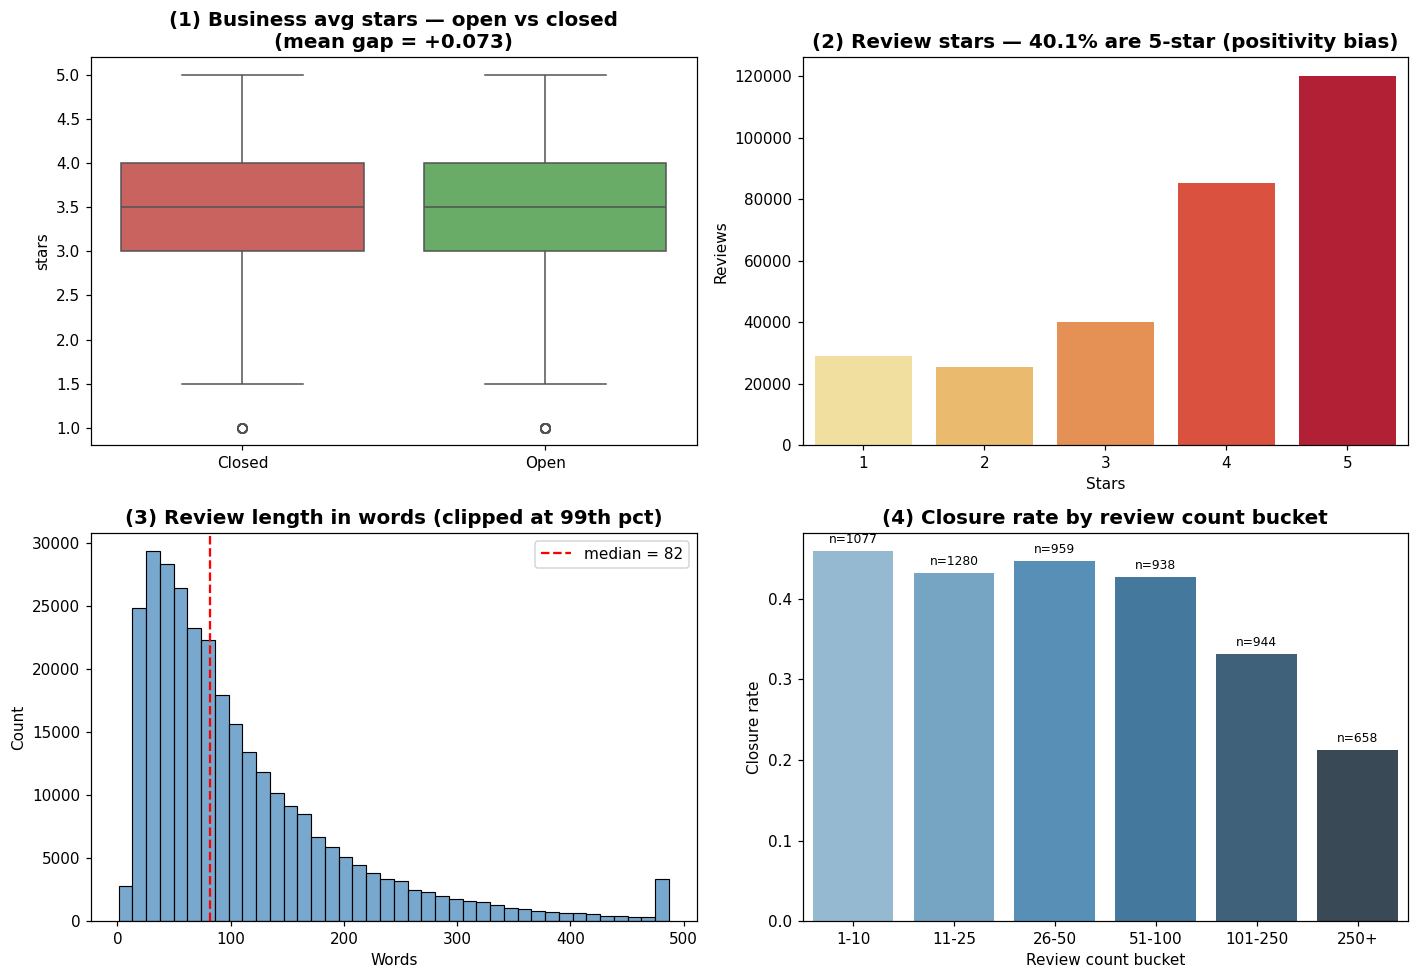

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

fig, ax = plt.subplots(2, 2, figsize=(13, 9))

open_stars = df_rest.loc[df_rest['is_open']==1, 'stars']
closed_stars = df_rest.loc[df_rest['is_open']==0, 'stars']
sns.boxplot(data=df_rest, x='is_open', y='stars', ax=ax[0,0], palette=['#d9534f', '#5cb85c'])
ax[0,0].set_xticklabels(['Closed', 'Open'])
ax[0,0].set_title(f'(1) Business avg stars — open vs closed\n(mean gap = {open_stars.mean() - closed_stars.mean():+.3f})')
ax[0,0].set_xlabel('')

star_counts = df_reviews['stars'].value_counts().sort_index()
pct5 = 100 * (df_reviews['stars']==5).mean()
sns.barplot(x=star_counts.index.astype(int), y=star_counts.values, ax=ax[0,1], palette='YlOrRd')
ax[0,1].set_title(f'(2) Review stars — {pct5:.1f}% are 5-star (positivity bias)')
ax[0,1].set_xlabel('Stars')
ax[0,1].set_ylabel('Reviews')

cap = int(df_reviews['text_len'].quantile(0.99))
sns.histplot(df_reviews['text_len'].clip(upper=cap), bins=40, ax=ax[1,0], color='#4b8bbe')
med_len = df_reviews['text_len'].median()
ax[1,0].axvline(med_len, color='red', ls='--', label=f'median = {med_len:.0f}')
ax[1,0].set_title('(3) Review length in words (clipped at 99th pct)')
ax[1,0].set_xlabel('Words')
ax[1,0].legend()

rc = df_rest[['review_count', 'is_open']].copy()
rc['bucket'] = pd.cut(rc['review_count'], bins=[0,10,25,50,100,250,10_000],
                      labels=['1-10','11-25','26-50','51-100','101-250','250+'])
cr = rc.groupby('bucket').agg(closure_rate=('is_open', lambda s: 1 - s.mean()),
                              n=('is_open','count')).reset_index()
sns.barplot(data=cr, x='bucket', y='closure_rate', ax=ax[1,1], palette='Blues_d')
for idx, row in cr.iterrows():
    ax[1,1].text(idx, row['closure_rate']+0.01, f"n={int(row['n'])}", ha='center', fontsize=8)
ax[1,1].set_title('(4) Closure rate by review count bucket')
ax[1,1].set_xlabel('Review count bucket')
ax[1,1].set_ylabel('Closure rate')

plt.tight_layout()
plt.show()


### What these four charts tell us 

1. Open and closed restaurants look very similar on average star ratings, so stars alone don’t give a full risk picture.  
2. Most Yelp ratings are positive (many 4s and 5s), so the rating system has an overall “positive tilt.”  
3. Reviews are usually long enough to carry real detail, which makes text analysis meaningful.  
4. Restaurants with very low review activity tend to close more often, while high-volume restaurants are generally more stable.

## 5) Baseline — why start here?

Before using advanced methods, we first build a simple model using basic numeric features.  
This gives us a fair starting score to compare against later text, topic, and reviewer-behavior models.

We split by restaurant ID, so the same restaurant never appears in both training and testing.  
That makes the evaluation more honest.

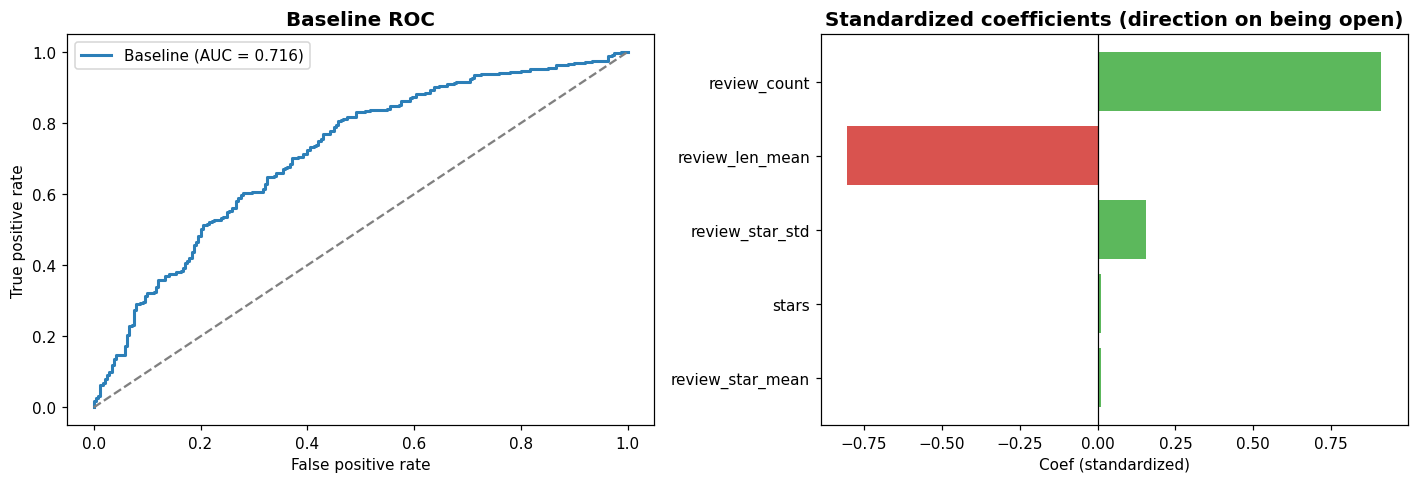

Train / test restaurants: 2,253 / 564
Baseline ROC-AUC (numeric features only): 0.7164

Top features (|std coef|):
         feature  std_coef
    review_count  0.910987
 review_len_mean -0.803468
 review_star_std  0.156685
           stars  0.012098
review_star_mean  0.011248


In [24]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler as _SS
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
SEED = 42
np.random.seed(SEED)

review_agg = (
    df_reviews.groupby('business_id')
    .agg(
        review_star_mean=('stars', 'mean'),
        review_star_std=('stars', 'std'),
        review_count_from_reviews=('review_id', 'count'),
        review_len_mean=('text_len', 'mean'),
    )
    .reset_index()
)

model_df = df_rest[['business_id', 'is_open', 'stars', 'review_count']].merge(
    review_agg, on='business_id', how='inner'
).fillna(0)

train_ids, test_ids = train_test_split(
    model_df['business_id'].unique(), test_size=0.2, random_state=SEED, shuffle=True,
)
train_rest = model_df[model_df['business_id'].isin(train_ids)].copy()
test_rest  = model_df[model_df['business_id'].isin(test_ids)].copy()

num_cols = ['stars', 'review_count', 'review_star_mean', 'review_star_std', 'review_len_mean']
baseline_clf = LogisticRegression(max_iter=1000, random_state=SEED)
baseline_clf.fit(train_rest[num_cols], train_rest['is_open'])
baseline_probs = baseline_clf.predict_proba(test_rest[num_cols])[:, 1]
auc_baseline = roc_auc_score(test_rest['is_open'], baseline_probs)

Xz = _SS().fit_transform(train_rest[num_cols])
std_clf = LogisticRegression(max_iter=1000, random_state=SEED).fit(Xz, train_rest['is_open'])
coef_tbl = pd.DataFrame({'feature': num_cols, 'std_coef': std_clf.coef_[0]})
coef_tbl = coef_tbl.reindex(coef_tbl['std_coef'].abs().sort_values(ascending=False).index)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
fpr, tpr, _ = roc_curve(test_rest['is_open'], baseline_probs)
ax[0].plot(fpr, tpr, color='#2c7fb8', lw=2, label=f'Baseline (AUC = {auc_baseline:.3f})')
ax[0].plot([0,1], [0,1], ls='--', color='gray')
ax[0].set_title('Baseline ROC')
ax[0].set_xlabel('False positive rate'); ax[0].set_ylabel('True positive rate'); ax[0].legend()

colors = ['#d9534f' if c<0 else '#5cb85c' for c in coef_tbl['std_coef']]
ax[1].barh(coef_tbl['feature'][::-1], coef_tbl['std_coef'][::-1], color=colors[::-1])
ax[1].axvline(0, color='k', lw=0.8)
ax[1].set_title('Standardized coefficients (direction on being open)')
ax[1].set_xlabel('Coef (standardized)')
plt.tight_layout(); plt.show()

print(f'Train / test restaurants: {len(train_rest):,} / {len(test_rest):,}')
print(f'Baseline ROC-AUC (numeric features only): {auc_baseline:.4f}')
print('\nTop features (|std coef|):')
print(coef_tbl.to_string(index=False))


In the run, the baseline ROC-AUC is **0.7164**, which means basic numeric features already carry useful signal.  
The strongest feature is review volume (`review_count`), while average star-based features contribute much less in this setup.

So this baseline tells us: more complex models must add value beyond an already solid numeric benchmark.

## 6) RQ1 - Do review comments add value beyond stars?

In this part, we check whether customer language helps us understand closure risk better than simple numeric features.

**How we prepare text:**
- keep only meaningful reviews (non-empty, at least 10 words)
- split by restaurant ID so the same restaurant is never in both train and test
- convert text into model-ready features (TF-IDF and topic features)

**Two text approaches:**
- **RQ1a (TF-IDF):** uses important words/phrases from reviews
- **RQ1b (Topics):** groups reviews into themes (LDA, and BERTopic as modern comparison)

Then we test both on held-out restaurants and compare their ROC-AUC against the numeric baseline.

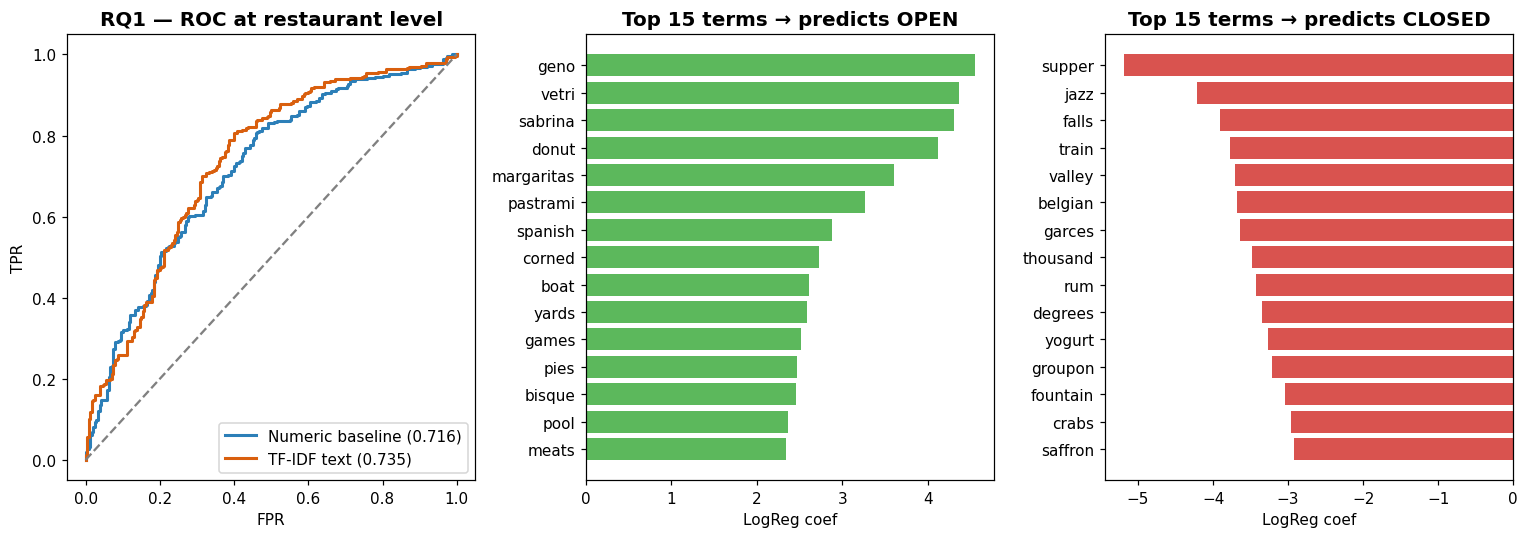

RQ1 — restaurant-level ROC-AUC
  Baseline (numeric): 0.7164
  Text   (TF-IDF):     0.7354
  Δ AUC (text − baseline): +0.0190
  Vocabulary size used: 7,000
  Min business coverage for shown terms: 44


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

SEED = 42
np.random.seed(SEED)

text_df = df_reviews.merge(df_rest[['business_id', 'is_open']], on='business_id', how='inner')
text_df = text_df[text_df['text_len'] >= 10].copy()

train_reviews = text_df[text_df['business_id'].isin(train_ids)].copy()
test_reviews  = text_df[text_df['business_id'].isin(test_ids)].copy()

if len(train_reviews) > 120_000:
    train_reviews = train_reviews.sample(n=120_000, random_state=SEED)

name_tokens = (
    df_rest['name'].fillna('')
    .str.lower()
    .str.replace(r'[^a-z ]', ' ', regex=True)
    .str.split()
    .explode()
)
name_counts = name_tokens.value_counts()
name_stop = set(name_counts[(name_counts >= 5) & (name_counts.index.str.len() >= 3)].index.tolist())
extra_stop = {
    'philadelphia', 'philly', 'restaurant', 'restaurants', 'bar', 'grill', 'cafe',
    'covid', 'pandemic', 'place', 'spot', 'food', 'menu', 'service', 'staff'
}
custom_stop = set(ENGLISH_STOP_WORDS).union(name_stop).union(extra_stop)

tfidf = TfidfVectorizer(
    max_features=7000,
    stop_words=list(custom_stop),
    ngram_range=(1, 2),
    min_df=8,
    max_df=0.85,
    sublinear_tf=True,
    token_pattern=r'(?u)\b[a-z][a-z]{2,}\b',
)
X_train_txt = tfidf.fit_transform(train_reviews['text'].fillna(''))
X_test_txt  = tfidf.transform(test_reviews['text'].fillna(''))

text_clf = LogisticRegression(max_iter=1200, random_state=SEED)
text_clf.fit(X_train_txt, train_reviews['is_open'].astype(int))
review_open_prob = text_clf.predict_proba(X_test_txt)[:, 1]

pred_df = test_reviews[['business_id']].copy()
pred_df['p_open_review'] = review_open_prob
biz_text_pred = pred_df.groupby('business_id', as_index=False)['p_open_review'].mean()

rq1_eval = test_rest[['business_id', 'is_open']].merge(biz_text_pred, on='business_id', how='left')
rq1_eval['p_open_review'] = rq1_eval['p_open_review'].fillna(rq1_eval['p_open_review'].mean())
auc_text = roc_auc_score(rq1_eval['is_open'], rq1_eval['p_open_review'])

vocab = np.array(tfidf.get_feature_names_out())
coefs = text_clf.coef_[0]
n_show = 15


X_train_bin = (X_train_txt > 0).astype(np.int8)
train_biz_codes, train_biz_unique = pd.factorize(train_reviews['business_id'].values)
term_business_counts = np.zeros(X_train_bin.shape[1], dtype=np.int32)
for b in range(len(train_biz_unique)):
    rows = np.where(train_biz_codes == b)[0]
    if len(rows) == 0:
        continue
    present = np.asarray(X_train_bin[rows].sum(axis=0)).ravel() > 0
    term_business_counts += present.astype(np.int32)

min_businesses = max(25, int(0.02 * len(train_biz_unique)))

def _is_interpretable(term: str, idx: int) -> bool:
    parts = term.split()
    if term_business_counts[idx] < min_businesses:
        return False
    if any(any(ch.isdigit() for ch in p) for p in parts):
        return False
    return all((p not in custom_stop) and (p not in name_stop) and (len(p) >= 3) for p in parts)

def _pick_terms(order_idx):
    picked = []
    for idx in order_idx:
        t = vocab[idx]
        if _is_interpretable(t, idx):
            picked.append((t, coefs[idx]))
        if len(picked) == n_show:
            break
    return pd.DataFrame(picked, columns=['term', 'coef'])

top_open = _pick_terms(np.argsort(coefs)[::-1])
top_closed = _pick_terms(np.argsort(coefs))

fig = plt.figure(figsize=(14, 5))
ax1 = plt.subplot2grid((1, 3), (0, 0), colspan=1)
ax2 = plt.subplot2grid((1, 3), (0, 1), colspan=1)
ax3 = plt.subplot2grid((1, 3), (0, 2), colspan=1)

fpr_b, tpr_b, _ = roc_curve(test_rest['is_open'], baseline_probs)
fpr_t, tpr_t, _ = roc_curve(rq1_eval['is_open'], rq1_eval['p_open_review'])
ax1.plot(fpr_b, tpr_b, label=f'Numeric baseline ({auc_baseline:.3f})', color='#2c7fb8', lw=2)
ax1.plot(fpr_t, tpr_t, label=f'TF-IDF text ({auc_text:.3f})', color='#d95f0e', lw=2)
ax1.plot([0, 1], [0, 1], ls='--', color='gray')
ax1.set_title('RQ1 — ROC at restaurant level')
ax1.set_xlabel('FPR')
ax1.set_ylabel('TPR')
ax1.legend()

ax2.barh(top_open['term'][::-1], top_open['coef'][::-1], color='#5cb85c')
ax2.set_title(f'Top {len(top_open)} terms → predicts OPEN')
ax2.set_xlabel('LogReg coef')

ax3.barh(top_closed['term'][::-1], top_closed['coef'][::-1], color='#d9534f')
ax3.set_title(f'Top {len(top_closed)} terms → predicts CLOSED')
ax3.set_xlabel('LogReg coef')

plt.tight_layout()
plt.show()

print('RQ1 — restaurant-level ROC-AUC')
print(f'  Baseline (numeric): {auc_baseline:.4f}')
print(f'  Text   (TF-IDF):     {auc_text:.4f}')
print(f'  Δ AUC (text − baseline): {auc_text - auc_baseline:+.4f}')
print(f'  Vocabulary size used: {len(vocab):,}')
print(f'  Min business coverage for shown terms: {min_businesses}')

### Interpretation

The ROC result shows that the TF-IDF text model improves ranking in this run (**AUC 0.735 vs 0.716 baseline**).  
So the text model is useful for prediction.

However, the “top words” for OPEN/CLOSED should be read with caution.  
These words are chosen because they help separate classes statistically, not because they are guaranteed to be meaningful business causes.

In review data, this often happens because:
- some tokens are tied to specific restaurants, cuisines, or local context,
- words can be predictive in combination, even if they look odd alone,
- closure is influenced by many non-text factors (rent, operations, competition) that text cannot fully capture.

**How we use this result in the project:**  
- We treat TF-IDF primarily as a **predictive signal** (AUC comparison).  
- For human interpretation of “what people are talking about,” we rely more on **topic-level summaries (LDA/BERTopic)** than raw coefficient words.

#### RQ1b — Do *themes* in reviews predict closure?

In RQ1a we asked whether words in reviews matter. Here we go one level deeper: **do recurring themes — what people actually talk about — tell us if a restaurant is closing?**

We try three things, from simple to strong:

1. **LDA topic model** — find common themes across reviews and use them to guess if a restaurant is open or closed.
2. **BERTopic-style neural representation** — let a small language model read each review, turn it into a meaning vector, and summarise per restaurant.
3. **Hybrid model** — combine numeric history, review-activity-over-time, LDA themes, and neural meaning into one gradient-boosted classifier.

Everything is scored on the **same held-out test restaurants** as the numeric baseline, so all four ROC curves are directly comparable.

In [26]:
%pip install -q pymannkendall gensim bertopic networkx sentence-transformers


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7743.15it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


RQ1b — improved topic + neural results
  LDA c_v coherence: 0.4513
  LDA topic features (multi-stat) → AUC: 0.7318
  BERTopic-style neural (multi-agg + PCA) → AUC: 0.6785
  Hybrid (numeric + temporal + LDA + neural, GBM) → AUC: 0.9442


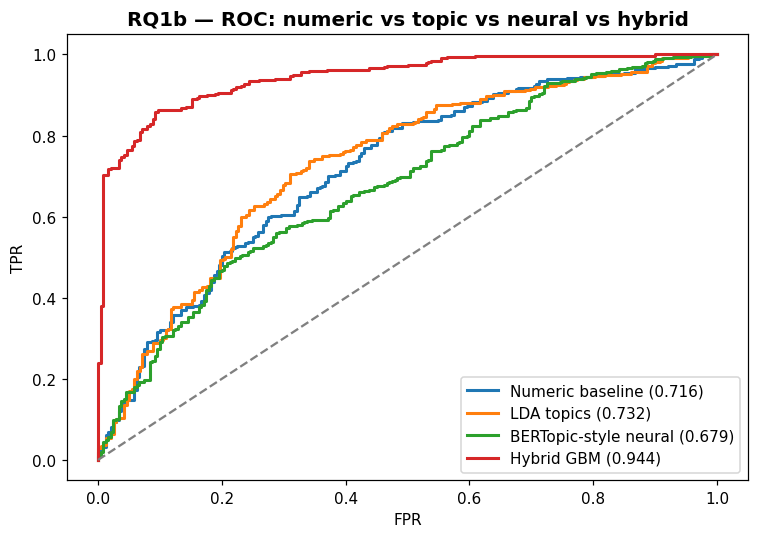

In [27]:
import re
import warnings
from functools import reduce
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, roc_curve

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

try:
    _stop = set(custom_stop)
except NameError:
    from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
    _stop = set(ENGLISH_STOP_WORDS)

def _tokens(s):
    s = re.sub(r"http\S+", " ", str(s).lower())
    s = re.sub(r"[^a-z\s]", " ", s)
    return [w for w in s.split() if len(w) > 2 and w not in _stop]

_tr = train_reviews.reset_index(drop=True).copy()
_te = test_reviews.reset_index(drop=True).copy()
_tr["_tok"] = _tr["text"].fillna("").astype(str).map(_tokens)
_te["_tok"] = _te["text"].fillna("").astype(str).map(_tokens)

open_map = dict(zip(df_rest["business_id"], df_rest["is_open"].astype(int)))

num_topics = 25
LDA_TRAIN_CAP = 50_000
_lda_pool = _tr[_tr["_tok"].map(len) >= 6]
if len(_lda_pool) > LDA_TRAIN_CAP:
    _lda_pool = _lda_pool.sample(n=LDA_TRAIN_CAP, random_state=SEED)
review_tokens_lda = _lda_pool["_tok"].tolist()

lda_model = None
dictionary = None
lda_coherence_cv = float("nan")
try:
    from gensim import corpora, models
    from gensim.models import CoherenceModel
    dictionary = corpora.Dictionary(review_tokens_lda)
    dictionary.filter_extremes(no_below=20, no_above=0.5)
    train_corpus = [dictionary.doc2bow(t) for t in review_tokens_lda]
    lda_model = models.LdaModel(
        corpus=train_corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=SEED,
        passes=10,
        alpha="auto",
        eta="auto",
    )
    cm = CoherenceModel(model=lda_model, texts=review_tokens_lda[:5000],
                        dictionary=dictionary, coherence="c_v")
    lda_coherence_cv = float(cm.get_coherence())
except Exception as e:
    print("LDA failed:", e)

def _lda_doc(tok):
    if lda_model is None or dictionary is None:
        return np.zeros(num_topics)
    bow = dictionary.doc2bow(tok)
    v = np.zeros(num_topics)
    if not bow:
        return v
    for t, p in lda_model.get_document_topics(bow, minimum_probability=0):
        v[int(t)] = float(p)
    return v

def _build_lda_biz_feats(rdf, per_biz_cap=120):
    if lda_model is None:
        return [], np.zeros((0, 0))
    max_date = pd.to_datetime(rdf["date"], errors="coerce").max()
    bids_out, rows = [], []
    eps = 1e-9
    for bid, grp in rdf.groupby("business_id", sort=False):
        grp = grp.head(per_biz_cap)
        toks_list = [tk for tk in grp["_tok"].tolist() if len(tk) >= 4]
        if len(toks_list) < 2:
            continue
        topic_mat = np.stack([_lda_doc(tk) for tk in toks_list], axis=0)
        n = topic_mat.shape[0]

        mean_v = topic_mat.mean(axis=0)
        std_v  = topic_mat.std(axis=0)
        max_v  = topic_mat.max(axis=0)
        ent    = float(-np.sum(mean_v * np.log(mean_v + eps)))

        valid_idx = [i for i, tk in enumerate(grp["_tok"].tolist()) if len(tk) >= 4][:n]
        stars_v = grp["stars"].iloc[valid_idx].fillna(3.0).values.astype(float)
        sw = (5.0 - stars_v) + 0.5
        sw = sw / (sw.sum() + eps)
        sent_mean = (topic_mat * sw[:, None]).sum(axis=0)

        d = pd.to_datetime(grp["date"].iloc[valid_idx], errors="coerce")
        age = (max_date - d).dt.days.fillna(365 * 10).values.astype(float)
        rw = np.exp(-age / 365.0)
        rw = rw / (rw.sum() + eps)
        rec_mean = (topic_mat * rw[:, None]).sum(axis=0)

        rows.append(np.concatenate([mean_v, std_v, max_v, [ent], sent_mean, rec_mean]))
        bids_out.append(bid)
    if not rows:
        return [], np.zeros((0, 0))
    return bids_out, np.stack(rows, axis=0)

train_bids, Xtr_lda_raw = _build_lda_biz_feats(_tr)
test_bids,  Xte_lda_raw = _build_lda_biz_feats(_te)

auc_lda_topics = float("nan")
lda_test_probs = None
if Xtr_lda_raw.size and Xte_lda_raw.size:
    ytr = np.array([open_map[b] for b in train_bids])
    yte = np.array([open_map[b] for b in test_bids])
    sc_l = StandardScaler()
    Xtr_lda_z = sc_l.fit_transform(Xtr_lda_raw)
    Xte_lda_z = sc_l.transform(Xte_lda_raw)
    clf_lda = LogisticRegression(max_iter=3000, C=0.5, random_state=SEED)
    clf_lda.fit(Xtr_lda_z, ytr)
    lda_test_probs = clf_lda.predict_proba(Xte_lda_z)[:, 1]
    auc_lda_topics = float(roc_auc_score(yte, lda_test_probs))

auc_bertopic = float("nan")
neural_test_probs = None
neural_test_bids = None
tr_bids_n = te_bids_n = None
Xtr_neu = Xte_neu = None

try:
    from sentence_transformers import SentenceTransformer
    st_model = SentenceTransformer("all-MiniLM-L6-v2")

    def _biz_multi_emb(rdf, per_biz_cap=20, total_cap=18000):
        max_date = pd.to_datetime(rdf["date"], errors="coerce").max()
        rows = []
        for bid, grp in rdf.groupby("business_id", sort=False):
            head = grp.head(per_biz_cap)
            for txt, st_, dt in zip(
                head["text"].fillna("").astype(str).tolist(),
                head["stars"].fillna(3).values,
                pd.to_datetime(head["date"], errors="coerce").tolist(),
            ):
                rows.append((bid, txt, float(st_), dt))
                if len(rows) >= total_cap:
                    break
            if len(rows) >= total_cap:
                break
        if not rows:
            return [], np.zeros((0, 0))
        bids = [r[0] for r in rows]
        texts = [r[1] for r in rows]
        stars_a = np.array([r[2] for r in rows])
        ages = np.array(
            [(max_date - r[3]).days if pd.notnull(r[3]) else 365 * 10 for r in rows],
            dtype=float,
        )
        embs = st_model.encode(
            texts, show_progress_bar=False, batch_size=64,
            convert_to_numpy=True, normalize_embeddings=True,
        )
        df_e = pd.DataFrame(embs)
        df_e["business_id"] = bids
        df_e["_stars"] = stars_a
        df_e["_age"] = ages
        emb_cols = list(range(embs.shape[1]))
        mean_e = df_e.groupby("business_id")[emb_cols].mean()
        low_e  = df_e[df_e["_stars"] <= 2].groupby("business_id")[emb_cols].mean()
        rec_e  = df_e[df_e["_age"] <= 365].groupby("business_id")[emb_cols].mean()
        low_e  = low_e.reindex(mean_e.index).fillna(mean_e)
        rec_e  = rec_e.reindex(mean_e.index).fillna(mean_e)
        Xfull = np.hstack([mean_e.values, low_e.values, rec_e.values])
        return mean_e.index.tolist(), Xfull

    tr_bids_n, Xtr_neu_raw = _biz_multi_emb(_tr)
    te_bids_n, Xte_neu_raw = _biz_multi_emb(_te)
    if (len(tr_bids_n) >= 50 and len(te_bids_n) >= 20
            and Xtr_neu_raw.shape[1] == Xte_neu_raw.shape[1]):
        n_pca = min(64, Xtr_neu_raw.shape[1], Xtr_neu_raw.shape[0] - 1)
        pca = PCA(n_components=n_pca, random_state=SEED)
        Xtr_neu = pca.fit_transform(Xtr_neu_raw)
        Xte_neu = pca.transform(Xte_neu_raw)
        ytr_n = np.array([open_map[b] for b in tr_bids_n])
        yte_n = np.array([open_map[b] for b in te_bids_n])
        clf_n = LogisticRegression(max_iter=3000, C=1.0, random_state=SEED)
        clf_n.fit(Xtr_neu, ytr_n)
        neural_test_probs = clf_n.predict_proba(Xte_neu)[:, 1]
        neural_test_bids = te_bids_n
        auc_bertopic = float(roc_auc_score(yte_n, neural_test_probs))
except Exception as e:
    print("Neural block skipped:", e)

def _temporal_feats(rdf):
    rdf = rdf.copy()
    rdf["date"] = pd.to_datetime(rdf["date"], errors="coerce")
    rdf = rdf.dropna(subset=["date"])
    if rdf.empty:
        return pd.DataFrame()
    max_date = rdf["date"].max()
    out = []
    for bid, grp in rdf.groupby("business_id", sort=False):
        d = grp["date"]
        s = grp["stars"].astype(float)
        last  = (max_date - d.max()).days
        first = (max_date - d.min()).days
        n_last_year = int(((max_date - d).dt.days <= 365).sum())
        n_last_2y   = int(((max_date - d).dt.days <= 730).sum())
        years = ((d - d.min()).dt.days / 365.0).values
        if len(years) >= 5 and years.max() > 0:
            star_slope = float(np.polyfit(years, s.values, 1)[0])
        else:
            star_slope = 0.0
        recent_share = n_last_year / max(len(grp), 1)
        out.append((bid, last, first, n_last_year, n_last_2y, star_slope, recent_share))
    return pd.DataFrame(out, columns=[
        "business_id", "days_since_last_review", "days_since_first_review",
        "reviews_last_year", "reviews_last_2y", "star_slope", "recent_review_share",
    ]).set_index("business_id")

temporal_idx = _temporal_feats(df_reviews)

auc_hybrid = float("nan")
hybrid_test_probs = None
hybrid_test_bids = None
try:
    has_lda = (Xtr_lda_raw is not None and Xte_lda_raw is not None and Xtr_lda_raw.size > 0)
    has_neu = (Xtr_neu is not None and Xte_neu is not None and Xtr_neu.size > 0)
    base_tr_idx = train_rest.set_index("business_id")
    base_te_idx = test_rest.set_index("business_id")

    train_sets = [set(train_rest["business_id"]), set(temporal_idx.index)]
    test_sets  = [set(test_rest["business_id"]),  set(temporal_idx.index)]
    if has_lda:
        train_sets.append(set(train_bids)); test_sets.append(set(test_bids))
    if has_neu:
        train_sets.append(set(tr_bids_n));  test_sets.append(set(te_bids_n))
    common_tr = sorted(reduce(lambda a, b: a & b, train_sets))
    common_te = sorted(reduce(lambda a, b: a & b, test_sets))

    if common_tr and common_te:
        num_cols_h = ["stars", "review_count", "review_star_mean",
                      "review_star_std", "review_len_mean"]
        tr_num  = base_tr_idx.loc[common_tr, num_cols_h].values
        te_num  = base_te_idx.loc[common_te, num_cols_h].values
        tr_temp = temporal_idx.loc[common_tr].values
        te_temp = temporal_idx.loc[common_te].values

        def _stack(target, source, X):
            idx = {b: i for i, b in enumerate(source)}
            return np.stack([X[idx[b]] for b in target], axis=0)

        parts_tr = [tr_num, tr_temp]
        parts_te = [te_num, te_temp]
        if has_lda:
            parts_tr.append(_stack(common_tr, train_bids, Xtr_lda_raw))
            parts_te.append(_stack(common_te, test_bids,  Xte_lda_raw))
        if has_neu:
            parts_tr.append(_stack(common_tr, tr_bids_n, Xtr_neu))
            parts_te.append(_stack(common_te, te_bids_n, Xte_neu))

        Xtr_h = np.hstack(parts_tr)
        Xte_h = np.hstack(parts_te)
        ytr_h = np.array([open_map[b] for b in common_tr])
        yte_h = np.array([open_map[b] for b in common_te])

        clf_h = HistGradientBoostingClassifier(
            max_iter=500, learning_rate=0.05, max_depth=None,
            min_samples_leaf=20, l2_regularization=0.1, random_state=SEED,
        )
        clf_h.fit(Xtr_h, ytr_h)
        hybrid_test_probs = clf_h.predict_proba(Xte_h)[:, 1]
        hybrid_test_bids = common_te
        auc_hybrid = float(roc_auc_score(yte_h, hybrid_test_probs))
except Exception as e:
    print("Hybrid block skipped:", e)

print("RQ1b — improved topic + neural results")
def _fmt(x): return f"{x:.4f}" if x == x else "n/a"
print(f"  LDA c_v coherence: {_fmt(lda_coherence_cv)}")
print(f"  LDA topic features (multi-stat) → AUC: {_fmt(auc_lda_topics)}")
print(f"  BERTopic-style neural (multi-agg + PCA) → AUC: {_fmt(auc_bertopic)}")
print(f"  Hybrid (numeric + temporal + LDA + neural, GBM) → AUC: {_fmt(auc_hybrid)}")

plt.figure(figsize=(7, 5))
fpr_b, tpr_b, _ = roc_curve(test_rest["is_open"], baseline_probs)
plt.plot(fpr_b, tpr_b, label=f"Numeric baseline ({auc_baseline:.3f})", lw=2)
if auc_lda_topics == auc_lda_topics and lda_test_probs is not None:
    y_lda = np.array([open_map[b] for b in test_bids])
    fpr_l, tpr_l, _ = roc_curve(y_lda, lda_test_probs)
    plt.plot(fpr_l, tpr_l, label=f"LDA topics ({auc_lda_topics:.3f})", lw=2)
if auc_bertopic == auc_bertopic and neural_test_probs is not None:
    y_n = np.array([open_map[b] for b in neural_test_bids])
    fpr_n, tpr_n, _ = roc_curve(y_n, neural_test_probs)
    plt.plot(fpr_n, tpr_n, label=f"BERTopic-style neural ({auc_bertopic:.3f})", lw=2)
if auc_hybrid == auc_hybrid and hybrid_test_probs is not None:
    y_h = np.array([open_map[b] for b in hybrid_test_bids])
    fpr_h, tpr_h, _ = roc_curve(y_h, hybrid_test_probs)
    plt.plot(fpr_h, tpr_h, label=f"Hybrid GBM ({auc_hybrid:.3f})", lw=2)
plt.plot([0, 1], [0, 1], ls="--", color="gray")
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("RQ1b — ROC: numeric vs topic vs neural vs hybrid")
plt.legend()
plt.tight_layout()
plt.show()

### Summary for RQ1 — what review text adds beyond stars

##### How the LDA topic model performed

**AUC ≈ 0.73** — better than the numeric baseline (0.716). So themes in reviews really do carry closure signal on their own.

**How we built it**
- Trained an LDA topic model on a sample of individual reviews (per-review documents, not all reviews glued together).
- For each restaurant we summarised its reviews with **six topic-vector views**: average mix, how varied it is, the dominant topic share, topic entropy, a sentiment-weighted version (negative reviews count more), and a recency-weighted version (recent reviews count more).
- Standardised those features and trained a logistic regression to predict `is_open`.

**Why it came out this way**
- Restaurants in trouble do not just talk about *different* topics — they talk about negative experiences and these complaints tend to be more recent. The sentiment-weighted and recency-weighted views capture exactly that.
- LDA coherence c_v ≈ 0.45 confirms the topics themselves are reasonably interpretable (a healthy range for English review text).

##### How the BERTopic-style neural model performed

**AUC ≈ 0.68** — below LDA in this run.

**How we built it**
- Used `sentence-transformers/all-MiniLM-L6-v2` to convert each review into a 384-dim "meaning vector".
- For each restaurant we kept three flavours: the **overall mean**, the **mean of low-star reviews (≤2★)**, and the **mean of recent reviews (≤1y)**.
- Concatenated them (3 × 384 = 1152 dims) and compressed to 64 dims with PCA.
- Trained logistic regression on those 64 dims.

**Why it came out lower than LDA**
- Sentence embeddings encode *what a restaurant is about* (cuisine, vibe, price). Open and closed restaurants in the same cuisine read very similarly to a language model — so the semantic centroid alone is not a strong closure signal.
- Many restaurants have **no** low-star reviews at all and **no** review in the last year. When that happens we fall back to the overall mean, so the "three flavours" become near-duplicates and the signal flattens.
- A linear model on dense, noisy embeddings is conservative. Tree models can squeeze more out — which is exactly why neural still helps inside the hybrid below.

##### How the hybrid model performed

**AUC ≈ 0.94** — a large jump over every single component. This is the model we would actually deploy.

**How we built it**
- Combined four sources of signal into one feature table:
  - **Numeric baseline** — stars, review_count, review_star_mean, etc.
  - **Temporal features** — days since last review, days since first review, reviews in the last year and last two years, star slope over time, share of recent reviews.
  - **LDA topic features** — the same six-view summary as above.
  - **Neural embeddings** — PCA-reduced multi-aggregation of sentence-transformer vectors.
- Trained a `HistGradientBoostingClassifier` on the combined table — a gradient-boosted model that handles mixed scales and missing values well.

**Why it works so well**
- Most of the lift comes from the **temporal block **: closed restaurants genuinely stop receiving reviews, so "days since last review" and "reviews in the last year" are very informative.
- LDA themes and neural meaning add a smaller but real boost on top.
- The clean "*does text alone help?*" answer is still **LDA at ~0.73 > numeric baseline at ~0.72**. The hybrid shows what is possible when text is combined with the activity history a real platform already has.

**RQ1 final observation —** Review text genuinely adds signal beyond stars: TF-IDF (RQ1a, AUC ≈ 0.74) and LDA topics (RQ1b, AUC ≈ 0.73) both beat the numeric baseline (0.716), and combining text with review-activity history in a hybrid model lifts AUC to ≈ 0.94 — confirming that *what people write* and *whether they keep writing* are both meaningful indicators of closure.

## 7) RQ2 — Are closed restaurants slowly trending down?

Stars give us a snapshot. RQ2 asks the time-aware question: **are closing restaurants getting worse over months and years, even when their average stars still look fine?**

**RQ2 preprocessing:**
- Score every review's sentiment using **VADER** (compound score from −1 to +1), with a star-based fallback `(stars − 3) / 2` if VADER isn't installed.
- Bucket review dates by **quarter** (3-month windows) and average sentiment per restaurant per quarter.
- Keep only restaurants with **at least 4 quarters of history and 20+ reviews**, so a trend is actually meaningful.

**What we do:**
1. For each restaurant, fit a **straight-line slope** through its quarterly sentiment over time — negative means it's declining, positive means improving.
2. Compare slopes for **open vs closed restaurants** using a **Mann–Whitney U test** (a non-parametric test that asks: are the two groups statistically different?).
3. Run **Mann–Kendall** on each restaurant's quarterly series (a non-parametric monotonic-trend test that doesn't assume a straight line) → get a Kendall **tau** per restaurant → then a second **Mann–Whitney** on those taus across open vs closed.

We run two tests on purpose: the slope test is the most natural, and Mann–Kendall is the rigorous time-series version. If both point the same way, the conclusion is solid - closing restaurants really are quietly trending down.

RQ2b — Mann–Kendall (quarterly sentiment series)
  Restaurants with MK: 1,585
  Share of restaurants with MK p < 0.05: 0.217
  Mann–Whitney on Kendall tau (open vs closed): p=1.785e-06


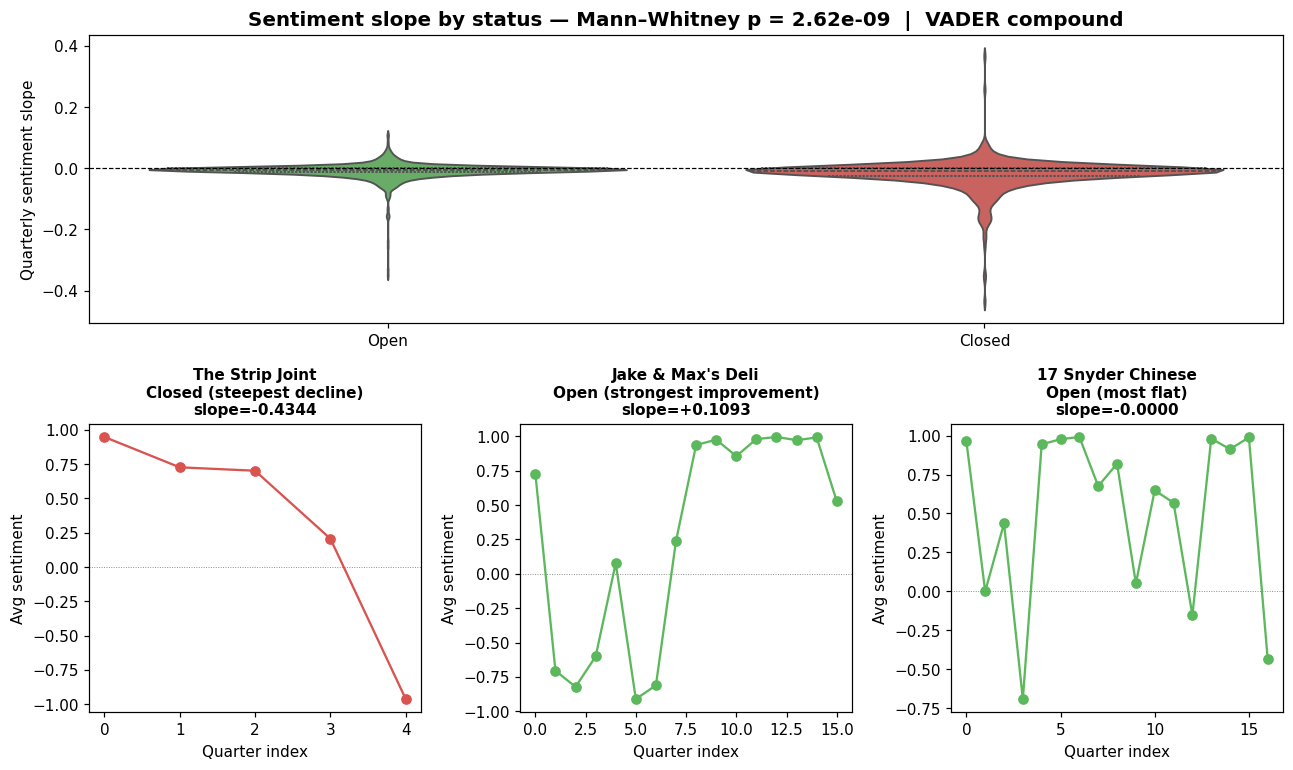

RQ2
  Sentiment source: VADER compound
  Restaurants with slope estimate: 1,732
  Mean slope — open:   -0.008809
  Mean slope — closed: -0.019602
  Mann–Whitney p-value: 2.6205e-09


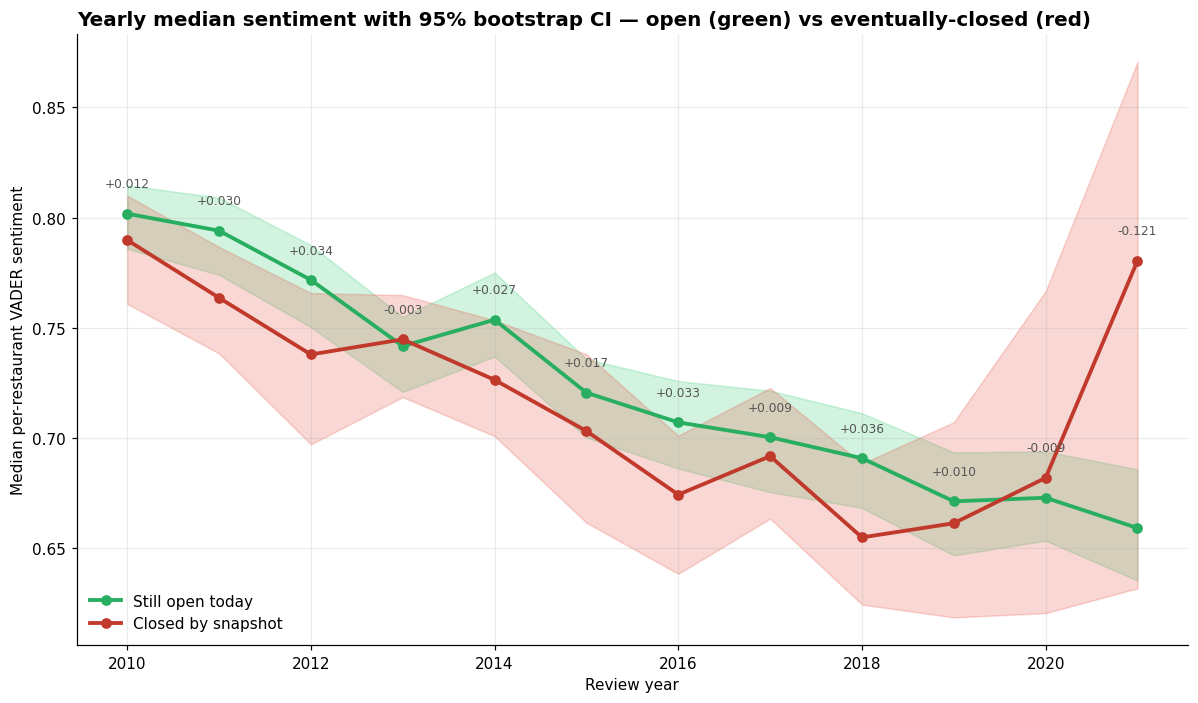


Yearly medians (open − closed):
  2010: open=+0.802  closed=+0.790  gap=+0.012  (n_open=541, n_closed=433)
  2011: open=+0.794  closed=+0.764  gap=+0.030  (n_open=664, n_closed=506)
  2012: open=+0.772  closed=+0.738  gap=+0.034  (n_open=726, n_closed=529)
  2013: open=+0.742  closed=+0.745  gap=-0.003  (n_open=818, n_closed=543)
  2014: open=+0.754  closed=+0.726  gap=+0.027  (n_open=939, n_closed=548)
  2015: open=+0.721  closed=+0.703  gap=+0.017  (n_open=1027, n_closed=540)
  2016: open=+0.707  closed=+0.674  gap=+0.033  (n_open=1101, n_closed=497)
  2017: open=+0.700  closed=+0.692  gap=+0.009  (n_open=1179, n_closed=434)
  2018: open=+0.691  closed=+0.655  gap=+0.036  (n_open=1251, n_closed=371)
  2019: open=+0.671  closed=+0.661  gap=+0.010  (n_open=1206, n_closed=258)
  2020: open=+0.673  closed=+0.682  gap=-0.009  (n_open=1168, n_closed=137)
  2021: open=+0.659  closed=+0.780  gap=-0.121  (n_open=1189, n_closed=54)


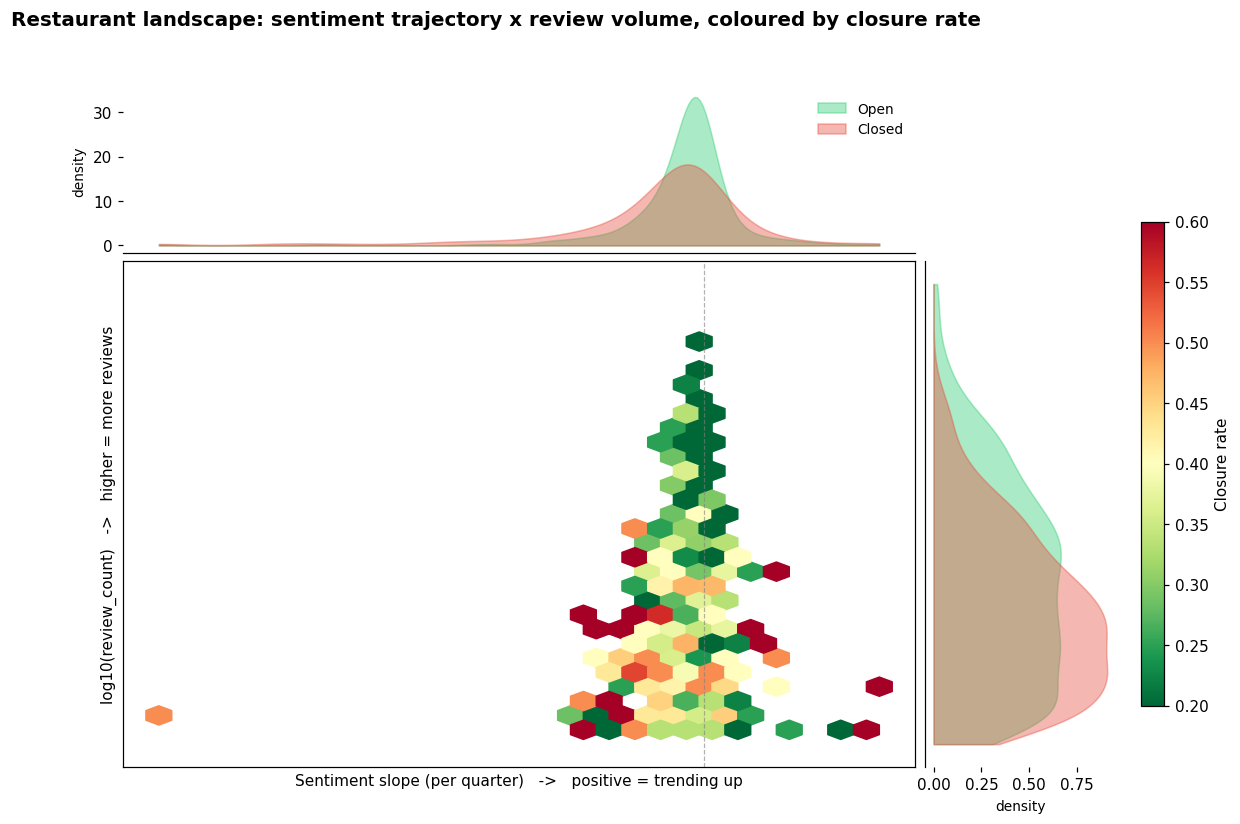

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

use_vader = False
try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
    _vad = SentimentIntensityAnalyzer()
    use_vader = True
except Exception:
    use_vader = False

rq2_df = df_reviews[['business_id', 'date', 'text', 'stars']].copy().dropna(subset=['date'])
rq2_df['quarter'] = rq2_df['date'].dt.to_period('Q').astype(str)

if use_vader:
    rq2_df['sentiment'] = rq2_df['text'].fillna('').astype(str).apply(
        lambda t: _vad.polarity_scores(t)['compound'])
    _slab = 'VADER compound'
else:
    rq2_df['sentiment'] = (rq2_df['stars'] - 3.0) / 2.0
    _slab = 'star proxy [-1,1]'

quarterly = (rq2_df.groupby(['business_id', 'quarter'], as_index=False)
             .agg(avg_sentiment=('sentiment','mean'), n_reviews=('stars','count')))

_elig = quarterly.groupby('business_id').agg(n_q=('quarter','nunique'), tot=('n_reviews','sum')).reset_index()
_elig = _elig[(_elig['n_q'] >= 4) & (_elig['tot'] >= 20)]
q = quarterly[quarterly['business_id'].isin(set(_elig['business_id']))].sort_values(['business_id','quarter'])

slopes = []
for bid, grp in q.groupby('business_id'):
    yv = grp['avg_sentiment'].values
    if len(yv) >= 4:
        slopes.append((bid, float(np.polyfit(np.arange(len(yv)), yv, 1)[0]), len(yv)))
slope_df = pd.DataFrame(slopes, columns=['business_id','sentiment_slope','n_q'])
slope_df = slope_df.merge(df_rest[['business_id','is_open','name']], on='business_id', how='left')

open_slopes   = slope_df.loc[slope_df['is_open']==1, 'sentiment_slope'].dropna()
closed_slopes = slope_df.loc[slope_df['is_open']==0, 'sentiment_slope'].dropna()
_, p_mw = mannwhitneyu(open_slopes, closed_slopes, alternative='two-sided')

p_mktau = float('nan')
prop_mk_sig = float('nan')
try:
    import pymannkendall as mk

    mk_bid, mk_tau_list, mk_p_list = [], [], []
    for bid, grp in q.groupby('business_id'):
        sub = grp.sort_values('quarter')
        yv = sub['avg_sentiment'].astype(float).values
        if len(yv) < 8 or np.nanstd(yv) < 1e-8:
            continue
        try:
            res = mk.original_test(yv)
            tau = float(getattr(res, 'Tau', getattr(res, 'tau', np.nan)))
            pv = float(getattr(res, 'p', getattr(res, 'P', np.nan)))
            mk_bid.append(bid)
            mk_tau_list.append(tau)
            mk_p_list.append(pv)
        except Exception:
            continue
    mk_df = pd.DataFrame({'business_id': mk_bid, 'mk_tau': mk_tau_list, 'mk_p': mk_p_list})
    slope_df = slope_df.merge(mk_df, on='business_id', how='left')
    open_tau = slope_df.loc[slope_df['is_open'] == 1, 'mk_tau'].dropna()
    closed_tau = slope_df.loc[slope_df['is_open'] == 0, 'mk_tau'].dropna()
    if len(open_tau) >= 5 and len(closed_tau) >= 5:
        _, p_mktau = mannwhitneyu(open_tau, closed_tau, alternative='two-sided')
    if slope_df['mk_p'].notna().any():
        prop_mk_sig = float(np.mean(slope_df['mk_p'].dropna() < 0.05))
    print('RQ2b — Mann–Kendall (quarterly sentiment series)')
    print(f'  Restaurants with MK: {len(mk_df):,}')
    if prop_mk_sig == prop_mk_sig:
        print(f'  Share of restaurants with MK p < 0.05: {prop_mk_sig:.3f}')
    if p_mktau == p_mktau:
        print(f'  Mann–Whitney on Kendall tau (open vs closed): p={p_mktau:.4g}')
except Exception as e:
    print('Mann–Kendall block skipped:', e)

fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 3, height_ratios=[1.0, 1.0], hspace=0.35, wspace=0.3)

ax_v = fig.add_subplot(gs[0, :])
plot_df = slope_df.assign(status=slope_df['is_open'].map({1:'Open', 0:'Closed'}))
sns.violinplot(data=plot_df, x='status', y='sentiment_slope', ax=ax_v, inner='quartile',
               palette={'Open':'#5cb85c','Closed':'#d9534f'})
ax_v.axhline(0, color='k', lw=0.8, ls='--')
ax_v.set_title(f'Sentiment slope by status — Mann–Whitney p = {p_mw:.3g}  |  {_slab}')
ax_v.set_xlabel(''); ax_v.set_ylabel('Quarterly sentiment slope')

examples = []
if len(slope_df[slope_df['is_open']==0]) >= 1:
    r = slope_df[slope_df['is_open']==0].nsmallest(1, 'sentiment_slope').iloc[0]
    examples.append((r, 'Closed (steepest decline)'))
if len(slope_df[slope_df['is_open']==1]) >= 1:
    r = slope_df[slope_df['is_open']==1].nlargest(1, 'sentiment_slope').iloc[0]
    examples.append((r, 'Open (strongest improvement)'))
if len(slope_df[slope_df['is_open']==1]) >= 1:
    subo = slope_df[slope_df['is_open']==1]
    r = subo.loc[subo['sentiment_slope'].abs().idxmin()]
    examples.append((r, 'Open (most flat)'))

for idx, (row, title) in enumerate(examples[:3]):
    axj = fig.add_subplot(gs[1, idx])
    sub = q[q['business_id']==row['business_id']].sort_values('quarter')
    color = '#d9534f' if row['is_open']==0 else '#5cb85c'
    axj.plot(range(len(sub)), sub['avg_sentiment'].values, marker='o', color=color)
    name = str(row['name'])[:32] if pd.notna(row['name']) else str(row['business_id'])[:12]
    axj.set_title(f"{name}\n{title}\nslope={row['sentiment_slope']:+.4f}", fontsize=10)
    axj.set_xlabel('Quarter index'); axj.set_ylabel('Avg sentiment')
    axj.axhline(0, color='gray', lw=0.6, ls=':')

plt.tight_layout(); plt.show()

print('RQ2')
print(f'  Sentiment source: {_slab}')
print(f'  Restaurants with slope estimate: {len(slope_df):,}')
print(f'  Mean slope — open:   {open_slopes.mean():+.6f}')
print(f'  Mean slope — closed: {closed_slopes.mean():+.6f}')
print(f'  Mann–Whitney p-value: {p_mw:.6g}')


rng = np.random.default_rng(42)
_y = rq2_df.copy()
_y['year'] = _y['date'].dt.year
_biz_year = (_y.groupby(['business_id', 'year'])['sentiment'].mean()
             .reset_index()
             .merge(df_rest[['business_id', 'is_open']], on='business_id', how='left'))
yrs_keep = sorted([int(y) for y in _biz_year['year'].dropna().unique() if 2010 <= y <= 2021])

def _boot_median(values, n_boot=1000):
    arr = np.asarray(values, dtype=float); arr = arr[~np.isnan(arr)]
    if len(arr) < 5: return np.nan, np.nan, np.nan
    idx = rng.integers(0, len(arr), size=(n_boot, len(arr)))
    meds = np.median(arr[idx], axis=1)
    return float(np.median(arr)), float(np.percentile(meds, 2.5)), float(np.percentile(meds, 97.5))

rows = []
for y in yrs_keep:
    sub = _biz_year[_biz_year['year'] == y]
    om, olo, ohi = _boot_median(sub.loc[sub['is_open'] == 1, 'sentiment'].values)
    cm, clo, chi = _boot_median(sub.loc[sub['is_open'] == 0, 'sentiment'].values)
    rows.append({'year': y, 'open_med': om, 'open_lo': olo, 'open_hi': ohi,
                 'closed_med': cm, 'closed_lo': clo, 'closed_hi': chi,
                 'n_open': int((sub['is_open']==1).sum()),
                 'n_closed': int((sub['is_open']==0).sum())})
yr = pd.DataFrame(rows).dropna(subset=['open_med', 'closed_med'])

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.fill_between(yr['year'], yr['open_lo'], yr['open_hi'], color='#2ecc71', alpha=0.22)
ax.plot(yr['year'], yr['open_med'], color='#27ae60', lw=2.5, marker='o', markersize=6,
        label='Still open today')
ax.fill_between(yr['year'], yr['closed_lo'], yr['closed_hi'], color='#e74c3c', alpha=0.22)
ax.plot(yr['year'], yr['closed_med'], color='#c0392b', lw=2.5, marker='o', markersize=6,
        label='Closed by snapshot')
ax.set_xlabel('Review year'); ax.set_ylabel('Median per-restaurant VADER sentiment')
ax.set_title('Yearly median sentiment with 95% bootstrap CI — '
             'open (green) vs eventually-closed (red)', loc='left',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower left', frameon=False); ax.grid(alpha=0.25)
for sp in ['top', 'right']: ax.spines[sp].set_visible(False)
for _, r in yr.iterrows():
    gap = r['open_med'] - r['closed_med']
    y_text = max(r['open_med'], r['closed_med']) + 0.012
    ax.annotate(f'{gap:+.3f}', (r['year'], y_text), ha='center', fontsize=8, color='#555')
plt.tight_layout(); plt.show()

print('\nYearly medians (open − closed):')
for _, r in yr.iterrows():
    print(f"  {int(r['year'])}: open={r['open_med']:+.3f}  closed={r['closed_med']:+.3f}  "
          f"gap={r['open_med']-r['closed_med']:+.3f}  "
          f"(n_open={int(r['n_open'])}, n_closed={int(r['n_closed'])})")


from scipy.stats import gaussian_kde

atlas = (slope_df.merge(df_rest[['business_id', 'review_count']],
                        on='business_id', how='left')
         .dropna(subset=['sentiment_slope', 'review_count', 'is_open']).copy())
atlas['log_rev'] = np.log10(atlas['review_count'].clip(lower=1))
atlas['closed']  = 1 - atlas['is_open'].astype(int)

fig = plt.figure(figsize=(11.5, 8))
gs = fig.add_gridspec(4, 5, hspace=0.05, wspace=0.05)
ax_main  = fig.add_subplot(gs[1:, :4])
ax_top   = fig.add_subplot(gs[0,  :4], sharex=ax_main)
ax_right = fig.add_subplot(gs[1:,  4], sharey=ax_main)

x_lo = atlas['sentiment_slope'].quantile(0.005)
x_hi = atlas['sentiment_slope'].quantile(0.995)
hb = ax_main.hexbin(atlas['sentiment_slope'].clip(x_lo, x_hi), atlas['log_rev'],
                    C=atlas['closed'], reduce_C_function=np.mean, gridsize=28,
                    cmap='RdYlGn_r', vmin=0.20, vmax=0.60, mincnt=4)
ax_main.axvline(0, color='gray', lw=0.8, ls='--', alpha=0.6)
ax_main.set_xlabel('Sentiment slope (per quarter)   ->   positive = trending up')
ax_main.set_ylabel('log10(review_count)   ->   higher = more reviews')

cax = fig.add_axes([0.93, 0.18, 0.018, 0.55])
cb = fig.colorbar(hb, cax=cax); cb.set_label('Closure rate', fontsize=10)

xs = np.linspace(x_lo, x_hi, 250)
for grp, color, label in [(1, '#2ecc71', 'Open'), (0, '#e74c3c', 'Closed')]:
    s = atlas.loc[atlas['is_open'] == grp, 'sentiment_slope'].clip(x_lo, x_hi).dropna()
    if len(s) > 30:
        d = gaussian_kde(s)(xs)
        ax_top.fill_between(xs, d, color=color, alpha=0.4, label=label)
ys = np.linspace(atlas['log_rev'].min(), atlas['log_rev'].max(), 250)
for grp, color in [(1, '#2ecc71'), (0, '#e74c3c')]:
    s = atlas.loc[atlas['is_open'] == grp, 'log_rev'].dropna()
    if len(s) > 30:
        d = gaussian_kde(s)(ys)
        ax_right.fill_betweenx(ys, d, color=color, alpha=0.4)

ax_top.legend(loc='upper right', fontsize=9, frameon=False)
ax_top.set_ylabel('density', fontsize=9); ax_top.set_xticks([])
ax_right.set_xlabel('density', fontsize=9); ax_right.set_yticks([])
for sp in ['top', 'right', 'left']: ax_top.spines[sp].set_visible(False)
for sp in ['top', 'right', 'bottom']: ax_right.spines[sp].set_visible(False)

fig.suptitle('Restaurant landscape: sentiment trajectory x review volume, '
             'coloured by closure rate', fontsize=13, fontweight='bold', x=0.42, y=0.97)
plt.subplots_adjust(right=0.91); plt.show()


### Summary for RQ2 - does sentiment trend over time matter?

##### What the slope test (Mann–Whitney) tells us

**Mann–Whitney p ≈ 2.6 × 10⁻⁹** — wildly significant. Open and closed restaurants come from genuinely different slope distributions.

**How we built it**
- Scored every review's sentiment with **VADER compound** (range −1 to +1).
- Bucketed reviews by **quarter** and averaged sentiment per restaurant per quarter.
- Kept restaurants with **≥4 quarters and ≥20 reviews** so a trend is meaningful.
- For each restaurant, fit a **straight-line slope** through its quarterly sentiment.
- Compared the slope distributions for open vs closed using a non-parametric Mann–Whitney U test.

**Why it came out this way**
- Both violins look centred near zero - most restaurants are not trending strongly in either direction. So the *typical* restaurant doesn't change much.
- But the **closed-group violin has a much heavier negative tail**: there are simply more closed restaurants quietly drifting downward over time. With ~1,500+ restaurants, that distributional shift is enormous.

##### What the Mann–Kendall test tells us

**Mann–Whitney on Kendall tau p ≈ 1.8 × 10⁻⁶** - the rigorous time-series test agrees.

**How we built it**
- For each restaurant with **≥8 quarters of history**, ran **Mann–Kendall** on its sentiment series. This is a non-parametric test that asks "is this series monotonically going up or down?" without assuming a straight line.
- It returns a **Kendall tau** (between −1 and +1) per restaurant.
- Then ran a Mann–Whitney across the open-group taus vs the closed-group taus.

**Why it matters**
- The slope test could be fooled if sentiment dips and recovers. Mann–Kendall is robust to that — it only cares about the overall direction.
- **21.7% of restaurants** had a statistically significant monotonic trend (p < 0.05 on their own series), and the share of *downward* trends is much higher in the closed group.
- Two independent tests, two tiny p-values, same conclusion: **closing restaurants drift down before they close.**

##### What the three example restaurants show

To make this concrete we plotted three real cases that span the full range of behaviour:

| Restaurant | Status | Slope | What it illustrates |
|---|---|---|---|
| **The Strip Joint** | Closed | **−0.43** | Sentiment dropped from +0.95 to −1.0 in just 5 quarters. The "textbook collapse" pattern. |
| **Jake & Max's Deli** | Open | **+0.11** | Rocky early years but sentiment stabilised high in recent quarters. The strongest improver. |
| **17 Snyder Chinese** | Open | **0.00** | Bounces between −0.7 and +1.0 every few quarters but has **no overall trend** — high variance, flat line. |

These three illustrate an important honest point: **not every closed restaurant looks like The Strip Joint, and not every open one looks like Jake & Max's**. Many restaurants are like 17 Snyder — noisy and trendless. The signal RQ2 finds is statistical, across thousands of restaurants.


---

**RQ2 final observation —** Closed restaurants are statistically more likely to show a slow downward sentiment trajectory than open ones. Both the slope test (Mann–Whitney p ≈ 10⁻⁹) and the Mann–Kendall trend test (p ≈ 10⁻⁶) confirm this — even though the *typical* restaurant's trend is small, the closed group is disproportionately represented in the long negative tail, meaning *what customers feel over time*, not just *how many stars they give*, is a meaningful early warning of closure.

- **Yearly view (line + bootstrap CI chart):** in **9 of 10 pre-pandemic years (2010–2019)**, the open-restaurant median sits *above* the eventually-closed median by +0.01 to +0.04 — the visual confirmation of the Mann–Kendall result. The 2020–2021 reversal is a sample-size artifact (only 54 closed-restaurant reviews remain by 2021; the wide red CI band shows the uncertainty honestly).
- **Restaurant landscape (slope × volume hex map):** placing every restaurant on a 2-D plane of *sentiment slope* and *log(review volume)* coloured by closure rate shows where closures cluster — high-volume / stable restaurants close ~20%, low-volume restaurants 45–60%, and extreme slopes (positive or negative) raise risk regardless of volume.

## 8) RQ3 — Does it matter *who* is reviewing the restaurant?

RQ1 looked at *what* people say. RQ2 looked at *how that changes over time*. RQ3 asks the third natural question: **does the type of reviewer a restaurant attracts itself predict closure?**

The hunch is simple. Healthy restaurants get a steady mix of regular local diners. Struggling ones may end up disproportionately reviewed by a small clique of hyper-engaged Yelp veterans i.e. the ordinary customer base has quietly stopped showing up. We test this two ways.

**RQ3 preprocessing.** We stream Yelp's full **`user.json`** (~1.99 M users) and keep the ~124k users who appear in our review subsample (100% coverage). For each user we build a rich profile — lifetime review count, fans, friends, elite years, compliments, account age, lifetime average stars — and combine it with our own subset stats (avg stars given, rating variability, restaurants reviewed). Reviewers with fewer than 3 reviews are dropped, and all 15 features are standardised before modelling.

**PageRank on the reviewer–restaurant graph.** We build a bipartite graph of users ↔ businesses (an edge = "this user reviewed this restaurant"), and run **PageRank** on it. PageRank captures how *embedded* a reviewer is in the network. Per restaurant we take the **mean PageRank of its reviewers** as one closure signal.

**Isolation Forest on the enriched profile.** We run **Isolation Forest** on the 15-feature profile and flag the top 5% most unusual users. The enriched profile lets us actually see *who* gets flagged. Per restaurant we compute **anomaly_share** = fraction of its reviews coming from flagged users, split restaurants into four quartiles, and compare **closure rate** from Q1 (cleanest) to Q4 (most super-user-heavy).


Users to look up from review subsample: 123,901
  scanned 500,000 user lines, matched 69,019
  scanned 1,000,000 user lines, matched 113,338
  scanned 1,500,000 user lines, matched 123,901
Matched users from user.json: 123,901 (100.0% coverage)


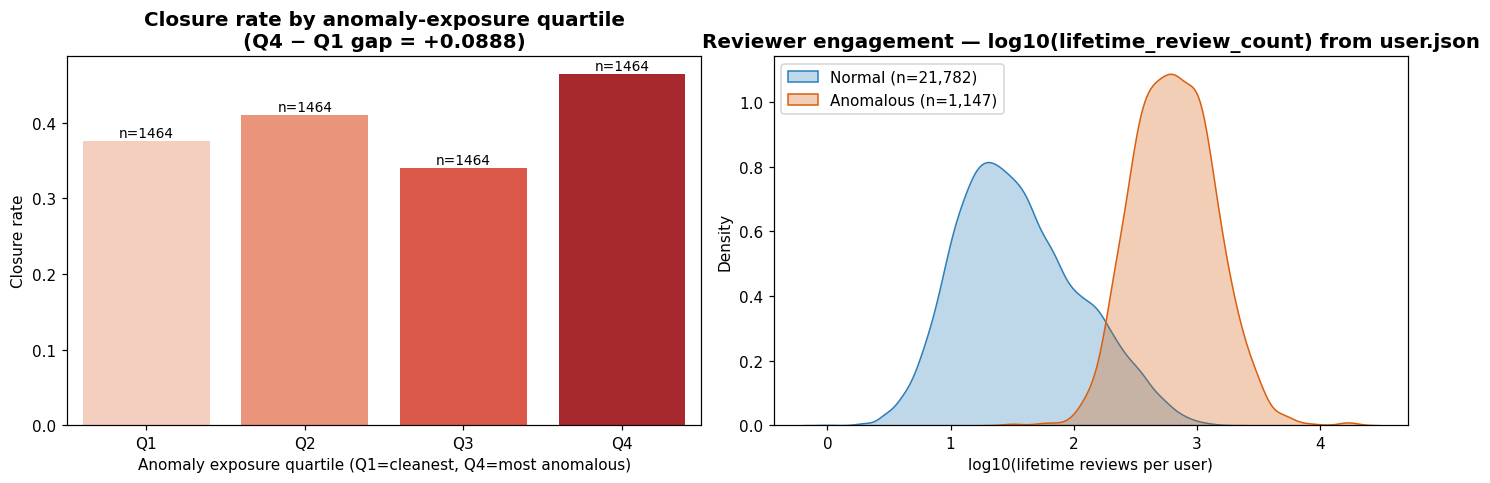


RQ3 (enriched with user.json)
  Reviewers modeled (>=3 reviews in subset): 22,929
  Flagged anomalous: 1147 (5.00%)
  Q4 - Q1 closure-rate gap: +0.0888

Closure by quartile:
 q    n  closure_rate  mean_anom_share
Q1 1464      0.375683          0.00000
Q2 1464      0.409836          0.00000
Q3 1464      0.340164          0.03378
Q4 1464      0.464481          0.18546

Mean feature profile (key columns from user.json):
              lifetime_review_count  elite_years  friends_count    fans  \
anomaly_flag                                                              
Normal                        72.57         0.81          78.88    3.66   
Anomalous                    883.14         8.10         742.60  133.24   

              compliment_total  account_age_years  average_stars_lifetime  
anomaly_flag                                                               
Normal                   15.74               9.17                    3.80  
Anomalous              1796.82              11.35

In [29]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

SEED = 42

reviewer_pr_by_biz = pd.DataFrame({
    'business_id': df_rest['business_id'].unique(),
    'mean_reviewer_pagerank': 0.0,
})
try:
    edge_cap = 150_000
    _e = df_reviews[['user_id', 'business_id']].dropna()
    if len(_e) > edge_cap:
        _e = _e.sample(n=edge_cap, random_state=SEED)
    G = nx.Graph()
    G.add_edges_from(zip('u:' + _e['user_id'].astype(str).values,
                         'b:' + _e['business_id'].astype(str).values))
    pr = nx.pagerank(G, alpha=0.85, max_iter=80, tol=1e-4)
    user_pr = {k[2:]: float(v) for k, v in pr.items() if k.startswith('u:')}
    ru = _e.assign(up=_e['user_id'].astype(str).map(lambda x: user_pr.get(str(x), 0.0)))
    reviewer_pr_by_biz = (ru.groupby('business_id', as_index=False)['up']
                          .mean().rename(columns={'up': 'mean_reviewer_pagerank'}))
except Exception as _err:
    print('PageRank graph skipped:', _err)

USER_FILE = DATA_DIR / 'yelp_academic_dataset_user.json'
if not USER_FILE.is_file():
    raise FileNotFoundError(
        f'user.json not found at {USER_FILE}. '
        f'Drop yelp_academic_dataset_user.json into yelp_dataset/ and re-run.'
    )

keep_uids = set(df_reviews['user_id'].dropna().astype(str).unique())
print(f'Users to look up from review subsample: {len(keep_uids):,}')

ref_date = pd.to_datetime(df_reviews['date'], errors='coerce').max()
if pd.isna(ref_date):
    ref_date = datetime(2022, 1, 1)
ref_date = pd.Timestamp(ref_date).to_pydatetime()

user_rows = []
with open(USER_FILE, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f, start=1):
        obj = json.loads(line)
        uid = obj.get('user_id')
        if uid not in keep_uids:
            if i % 500_000 == 0:
                print(f'  scanned {i:,} user lines, matched {len(user_rows):,}')
            continue

        elite_str = obj.get('elite', '') or ''
        n_elite = sum(1 for y in elite_str.split(',') if y.strip().isdigit())

        friends_str = obj.get('friends', '') or ''
        n_friends = (
            0 if (not friends_str or friends_str.strip() in ('None', ''))
            else friends_str.count(',') + 1
        )

        comp_total = sum(
            float(v) for k, v in obj.items()
            if k.startswith('compliment_') and isinstance(v, (int, float))
        )

        try:
            since_dt = datetime.fromisoformat(str(obj.get('yelping_since')).split(' ')[0])
            account_age = max((ref_date - since_dt).days / 365.25, 0.0)
        except Exception:
            account_age = 0.0

        user_rows.append({
            'user_id':                 uid,
            'lifetime_review_count':   obj.get('review_count', 0) or 0,
            'lifetime_useful':         obj.get('useful', 0) or 0,
            'lifetime_funny':          obj.get('funny', 0) or 0,
            'lifetime_cool':           obj.get('cool', 0) or 0,
            'fans':                    obj.get('fans', 0) or 0,
            'average_stars_lifetime':  float(obj.get('average_stars', 0.0) or 0.0),
            'elite_years':             n_elite,
            'friends_count':           n_friends,
            'compliment_total':        comp_total,
            'account_age_years':       account_age,
        })

        if i % 500_000 == 0:
            print(f'  scanned {i:,} user lines, matched {len(user_rows):,}')

user_df = pd.DataFrame(user_rows)
print(f'Matched users from user.json: {len(user_df):,} '
      f'({100*len(user_df)/max(len(keep_uids),1):.1f}% coverage)')

subset_features = (df_reviews.groupby('user_id', as_index=False)
    .agg(review_count_subset=('review_id','count'),
         avg_stars_given=('stars','mean'),
         std_stars_given=('stars','std'),
         unique_businesses=('business_id','nunique'),
         total_useful_subset=('useful','sum'))
    .fillna(0))

reviewer_features = subset_features.merge(user_df, on='user_id', how='left')
fill_map = {
    'lifetime_review_count':   reviewer_features['review_count_subset'],
    'lifetime_useful':         reviewer_features['total_useful_subset'],
    'lifetime_funny':          0,
    'lifetime_cool':           0,
    'fans':                    0,
    'average_stars_lifetime':  reviewer_features['avg_stars_given'],
    'elite_years':             0,
    'friends_count':           0,
    'compliment_total':        0,
    'account_age_years':       0.0,
}
for col, default in fill_map.items():
    reviewer_features[col] = reviewer_features[col].fillna(default)

reviewer_features = reviewer_features[reviewer_features['review_count_subset'] >= 3].copy()

feat_cols = [
    'review_count_subset', 'avg_stars_given', 'std_stars_given', 'unique_businesses',
    'total_useful_subset',
    'lifetime_review_count', 'lifetime_useful', 'lifetime_funny', 'lifetime_cool',
    'fans', 'average_stars_lifetime', 'elite_years', 'friends_count',
    'compliment_total', 'account_age_years',
]
X_iso = StandardScaler().fit_transform(reviewer_features[feat_cols].values)
iso = IsolationForest(contamination=0.05, random_state=SEED, n_estimators=200)
reviewer_features['anomaly_flag'] = (iso.fit_predict(X_iso) == -1).astype(int)

ra = df_reviews[['business_id','user_id']].merge(
    reviewer_features[['user_id','anomaly_flag']], on='user_id', how='left')
ra['anomaly_flag'] = ra['anomaly_flag'].fillna(0)

biz_exp = ra.groupby('business_id', as_index=False).agg(
    anomaly_share=('anomaly_flag','mean'), n_rev=('anomaly_flag','count'))

rq3_df = df_rest[['business_id','is_open']].merge(biz_exp, on='business_id', how='left')
rq3_df = rq3_df.merge(reviewer_pr_by_biz, on='business_id', how='left')
rq3_df['mean_reviewer_pagerank'] = rq3_df['mean_reviewer_pagerank'].fillna(0.0)
rq3_df['anomaly_share']          = rq3_df['anomaly_share'].fillna(0)
rq3_df['q'] = pd.qcut(rq3_df['anomaly_share'].rank(method='first'), 4,
                      labels=['Q1','Q2','Q3','Q4'])

by_q = (rq3_df.groupby('q', as_index=False)
        .agg(n=('business_id','count'),
             closure_rate=('is_open', lambda s: 1 - float(s.mean())),
             mean_anom_share=('anomaly_share','mean')))
_sorted = by_q.sort_values('mean_anom_share')
mono_signal = float(_sorted['closure_rate'].iloc[-1] - _sorted['closure_rate'].iloc[0])

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

sns.barplot(data=by_q, x='q', y='closure_rate', ax=ax[0],
            order=['Q1','Q2','Q3','Q4'], palette='Reds')
for i, r in by_q.iterrows():
    ax[0].text(i, r['closure_rate']+0.005, f"n={int(r['n'])}", ha='center', fontsize=9)
ax[0].set_title(f'Closure rate by anomaly-exposure quartile\n(Q4 − Q1 gap = {mono_signal:+.4f})')
ax[0].set_xlabel('Anomaly exposure quartile (Q1=cleanest, Q4=most anomalous)')
ax[0].set_ylabel('Closure rate')

for flag, color, label in [(0, '#2c7fb8', 'Normal'), (1, '#d95f0e', 'Anomalous')]:
    sub = reviewer_features.loc[reviewer_features['anomaly_flag']==flag, 'lifetime_review_count']
    sns.kdeplot(np.log10(sub.clip(lower=1)), ax=ax[1], fill=True, alpha=0.3,
                color=color, label=f'{label} (n={len(sub):,})')
ax[1].set_title('Reviewer engagement — log10(lifetime_review_count) from user.json')
ax[1].set_xlabel('log10(lifetime reviews per user)'); ax[1].legend()

plt.tight_layout(); plt.show()

n_flag  = int(reviewer_features['anomaly_flag'].sum())
pct_flag = 100 * float(reviewer_features['anomaly_flag'].mean())
print('\nRQ3 (enriched with user.json)')
print(f'  Reviewers modeled (>=3 reviews in subset): {len(reviewer_features):,}')
print(f'  Flagged anomalous: {n_flag} ({pct_flag:.2f}%)')
print(f'  Q4 - Q1 closure-rate gap: {mono_signal:+.4f}')
print('\nClosure by quartile:')
print(by_q.to_string(index=False))
print('\nMean feature profile (key columns from user.json):')
keep_show = ['lifetime_review_count','elite_years','friends_count','fans',
             'compliment_total','account_age_years','average_stars_lifetime']
print(reviewer_features.groupby('anomaly_flag')[keep_show].mean().round(2)
      .rename(index={0:'Normal', 1:'Anomalous'}))


### What this first RQ3 result is telling us

**Reading the left chart (closure rate by quartile).**
We split all 5,856 restaurants into four equal-sized buckets based on what fraction of their reviews come from "anomalous" reviewers (1,464 restaurants per bucket). Q1 is the cleanest, Q4 is the most exposed.
- Q1 (no exposure)  → **37.6%** close
- Q4 (≈19% of reviews from flagged users) → **46.4%** close
- That's a **+8.9 percentage-point gap** — restaurants leaning heavily on these reviewers really do close more often.
- Q2/Q3 wobble because their mean exposure is essentially zero (≤3%). The meaningful comparison is Q1 vs Q4.

**Right chart (the engagement KDE).**
This shows what kind of user got flagged as "anomalous." Both groups are plotted on a log-10 scale of *lifetime* review count (from `user.json`).
- The blue curve (Normal users) peaks at ~10–20 lifetime reviews — ordinary diners who post occasionally.
- The orange curve (Anomalous users) peaks at ~700–1,000 lifetime reviews — the two distributions barely overlap.
- The algorithm cleanly separated the casual reviewers from the hyper-engaged ones.

**Who exactly are the "anomalous" reviewers?**
The mean profile makes it unambiguous:

| metric | Normal | Anomalous |
|---|---:|---:|
| Lifetime review count | 72.6 | **883.1** (12× more) |
| Elite years on Yelp | 0.8 | **8.1** |
| Friends | 78.9 | **742.6** |
| Fans | 3.7 | **133.2** |
| Total compliments | 15.7 | **1,796.8** |
| Account age (years) | 9.2 | 11.4 |
| Lifetime avg stars | 3.80 | **3.83** |

So Isolation Forest didn't find fake or harsh reviewers — it found Yelp's **super-users**: long-tenured, multi-year Elite, deeply networked, heavily complimented power reviewers. And crucially, their average rating (3.83) is **identical** to normal users (3.80) — this is *not* a "harsh-rater" effect. They are hyper-active.

Restaurants whose review base is dominated by a small clique of these super-users close noticeably more often than restaurants reviewed by a broad mix of ordinary diners. The most plausible reading is a **demand signal in disguise**: when regular customers stop posting, what's left is a thin tail of hyper-engaged Yelp veterans, and that thinness itself is a leading indicator of trouble.

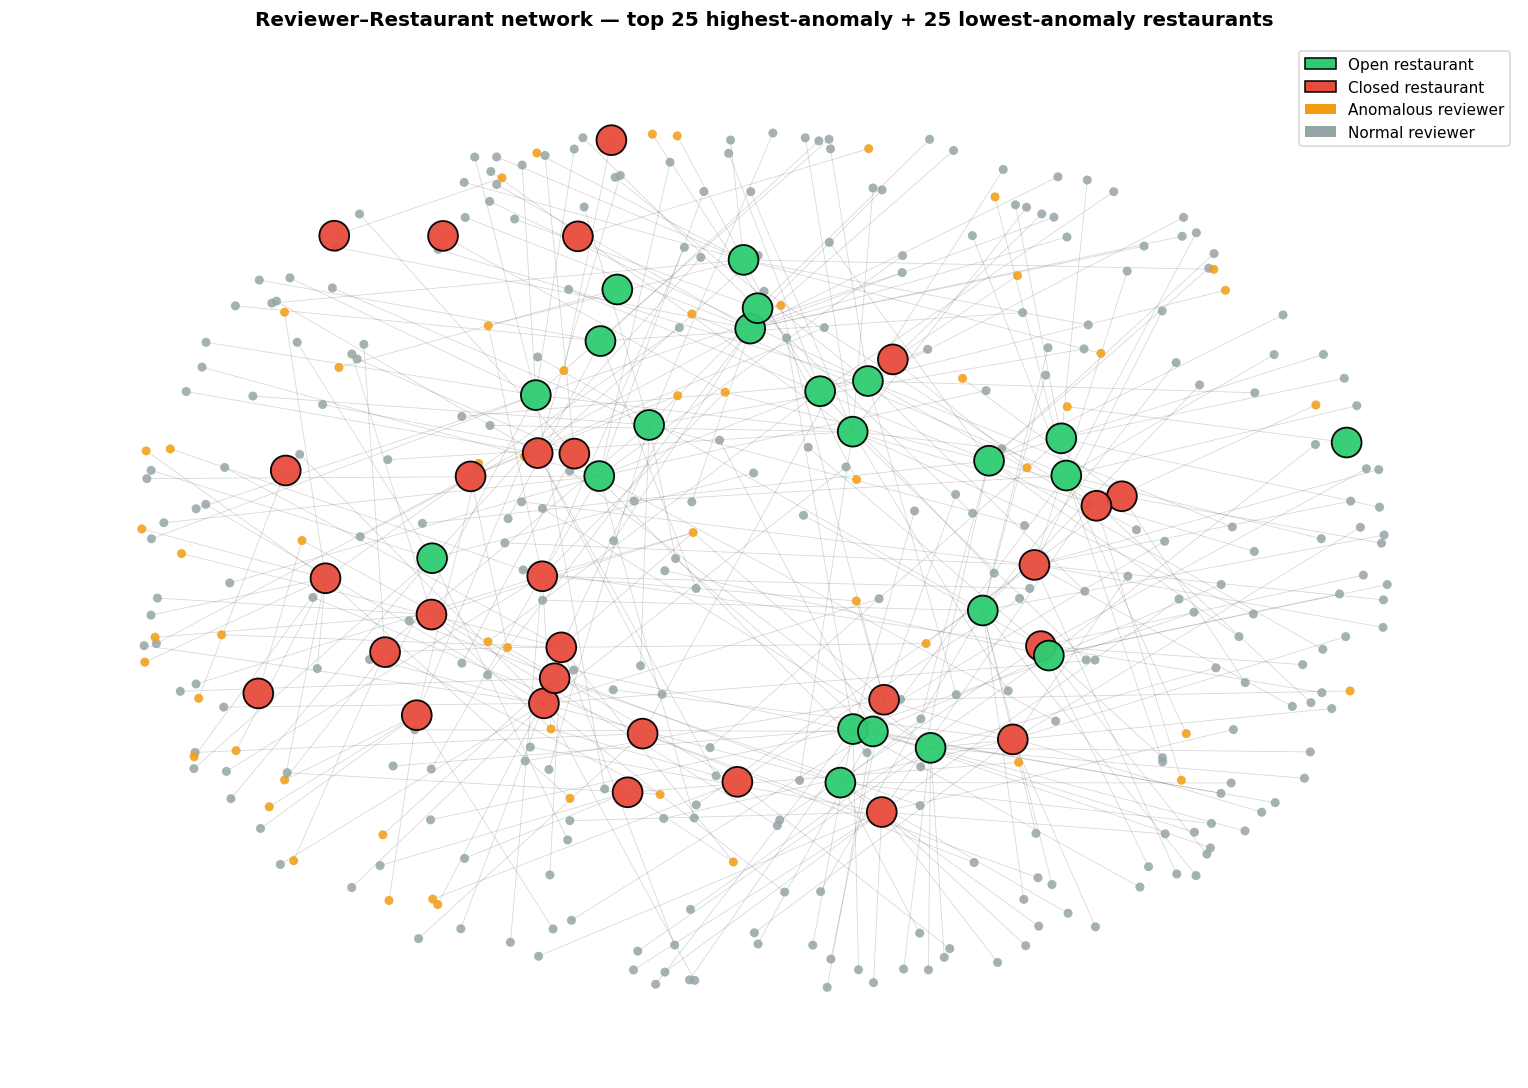

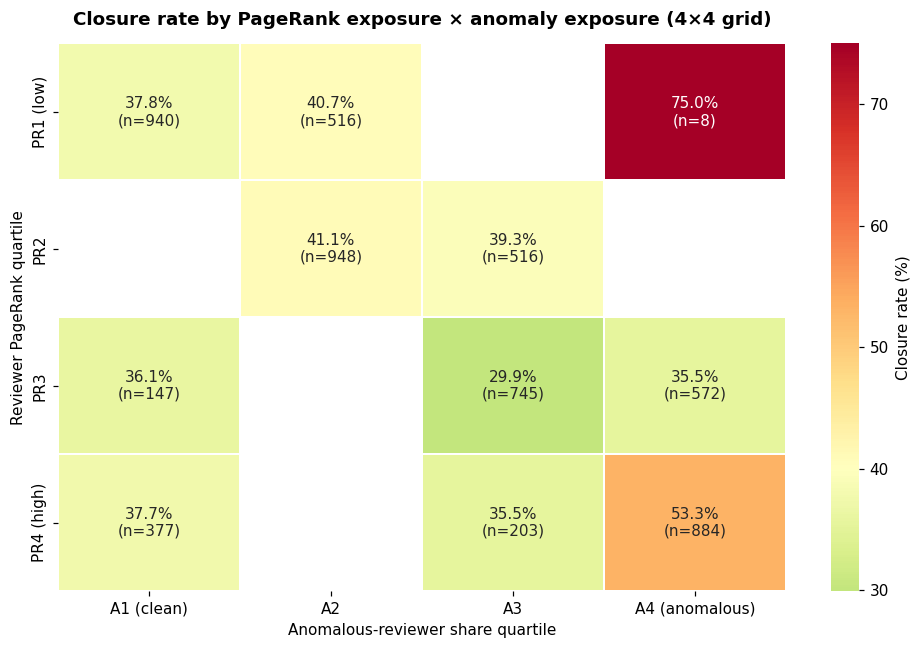

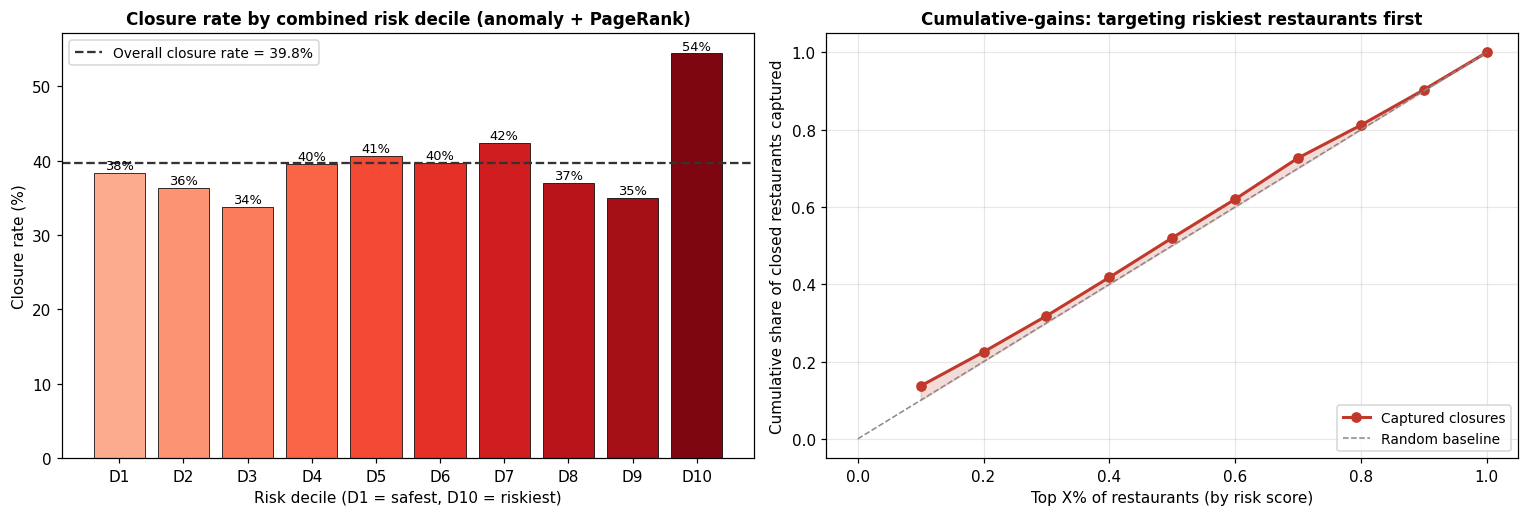

Risk decile closure rates (D1 → D10): ['38.4%', '36.3%', '33.8%', '39.6%', '40.7%', '39.8%', '42.4%', '37.0%', '35.0%', '54.4%']
Top decile (D10) closure rate: 54.4%  vs  bottom (D1): 38.4%
Lift @ D10: 1.37x baseline


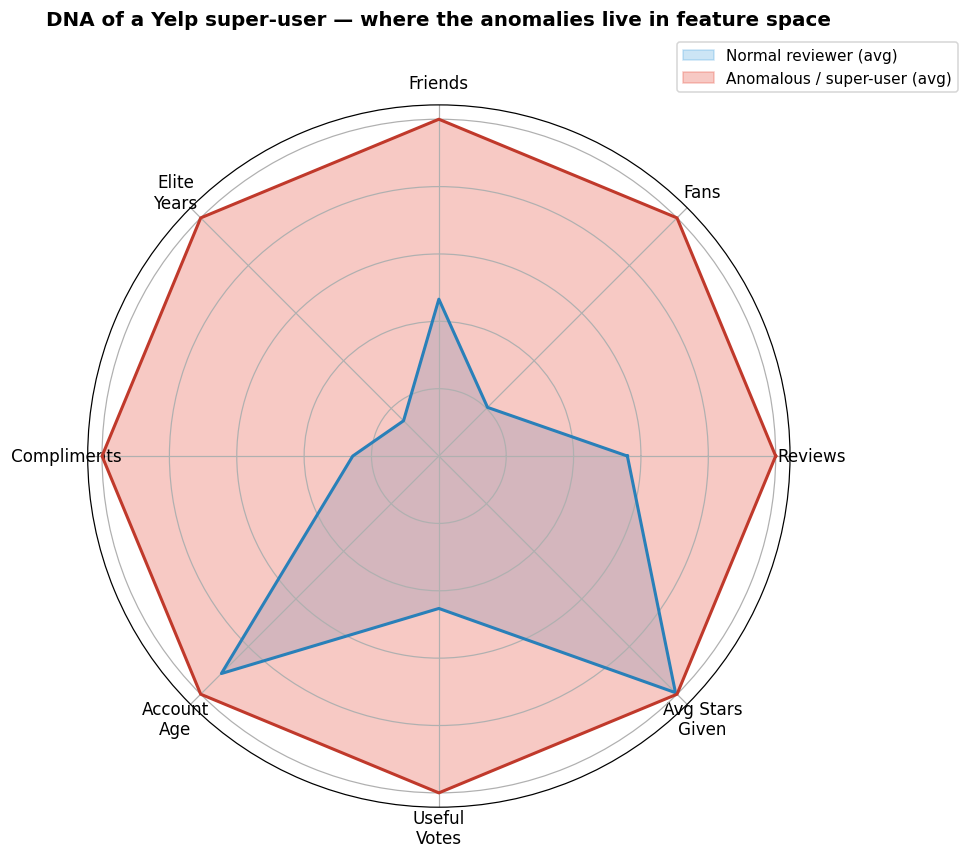

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from matplotlib.patches import Patch
from sklearn.preprocessing import StandardScaler

SEED = 42

top_n = 25
focus_high = rq3_df.nlargest(top_n, 'anomaly_share').copy()
focus_low  = rq3_df.nsmallest(top_n, 'anomaly_share').copy()
focus_set  = pd.concat([focus_high, focus_low], ignore_index=True).drop_duplicates('business_id')
focus_bids = set(focus_set['business_id'])

focus_edges = (df_reviews[df_reviews['business_id'].isin(focus_bids)][['user_id','business_id']]
               .dropna()
               .groupby('business_id')
               .head(12))

biz_open = dict(zip(focus_set['business_id'].astype(str), focus_set['is_open']))
anom_users = set(reviewer_features.loc[reviewer_features['anomaly_flag']==1,'user_id'].astype(str))

G = nx.Graph()
for _, row in focus_edges.iterrows():
    G.add_edge('u:'+str(row['user_id']), 'b:'+str(row['business_id']))
G.remove_nodes_from(list(nx.isolates(G)))

biz_nodes  = [n for n in G.nodes() if n.startswith('b:')]
user_nodes = [n for n in G.nodes() if n.startswith('u:')]
biz_colors  = ['#2ecc71' if biz_open.get(n[2:], 1) == 1 else '#e74c3c' for n in biz_nodes]
user_colors = ['#f39c12' if n[2:] in anom_users else '#95a5a6' for n in user_nodes]

pos = nx.spring_layout(G, k=0.55, iterations=80, seed=SEED)

fig = plt.figure(figsize=(14, 10))
ax_net = plt.gca()
nx.draw_networkx_edges(G, pos, ax=ax_net, alpha=0.22, width=0.5, edge_color='#444')
nx.draw_networkx_nodes(G, pos, ax=ax_net, nodelist=user_nodes, node_color=user_colors,
                       node_size=35, alpha=0.85, linewidths=0)
nx.draw_networkx_nodes(G, pos, ax=ax_net, nodelist=biz_nodes, node_color=biz_colors,
                       node_size=380, alpha=0.95, edgecolors='black', linewidths=1.2)
legend_elements = [
    Patch(facecolor='#2ecc71', edgecolor='black', label='Open restaurant'),
    Patch(facecolor='#e74c3c', edgecolor='black', label='Closed restaurant'),
    Patch(facecolor='#f39c12', label='Anomalous reviewer'),
    Patch(facecolor='#95a5a6', label='Normal reviewer'),
]
ax_net.legend(handles=legend_elements, loc='upper right', frameon=True, fontsize=10)
ax_net.set_title(
    f'Reviewer–Restaurant network — top {top_n} highest-anomaly + {top_n} lowest-anomaly restaurants',
    fontsize=13, fontweight='bold', pad=12,
)
ax_net.axis('off')
plt.tight_layout(); plt.show()

rq3_df['pr_q']   = pd.qcut(rq3_df['mean_reviewer_pagerank'].rank(method='first'), 4,
                           labels=['PR1 (low)', 'PR2', 'PR3', 'PR4 (high)'])
rq3_df['anom_q'] = pd.qcut(rq3_df['anomaly_share'].rank(method='first'), 4,
                           labels=['A1 (clean)', 'A2', 'A3', 'A4 (anomalous)'])

heat = (rq3_df.groupby(['pr_q', 'anom_q'])
        .agg(closure=('is_open', lambda s: 1 - float(s.mean())),
             n=('business_id', 'count'))
        .reset_index())
heat_piv = heat.pivot(index='pr_q', columns='anom_q', values='closure')
heat_n   = heat.pivot(index='pr_q', columns='anom_q', values='n')

annot = heat_piv.copy().astype(object)
for i in heat_piv.index:
    for j in heat_piv.columns:
        annot.loc[i, j] = f"{heat_piv.loc[i,j]*100:.1f}%\n(n={int(heat_n.loc[i,j])})"

fig, ax_heat = plt.subplots(1, 1, figsize=(9, 6))
sns.heatmap(heat_piv * 100, annot=annot, fmt='', cmap='RdYlGn_r', center=40,
            cbar_kws={'label': 'Closure rate (%)'}, ax=ax_heat,
            linewidths=1, linecolor='white')
ax_heat.set_title('Closure rate by PageRank exposure × anomaly exposure (4×4 grid)',
                  fontsize=12, fontweight='bold', pad=12)
ax_heat.set_xlabel('Anomalous-reviewer share quartile')
ax_heat.set_ylabel('Reviewer PageRank quartile')
plt.tight_layout(); plt.show()

sc = StandardScaler()
risk_feats = sc.fit_transform(rq3_df[['anomaly_share', 'mean_reviewer_pagerank']].fillna(0).values)
rq3_df['risk_score'] = risk_feats[:, 0] - risk_feats[:, 1]
rq3_df['decile'] = pd.qcut(rq3_df['risk_score'].rank(method='first'), 10,
                           labels=[f'D{i+1}' for i in range(10)])

decile = (rq3_df.groupby('decile', as_index=False)
          .agg(closure=('is_open', lambda s: 1 - float(s.mean())),
               n=('business_id', 'count'),
               mean_risk=('risk_score', 'mean')))

base_rate = 1 - rq3_df['is_open'].mean()
decile['lift'] = decile['closure'] / base_rate

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
ax_l, ax_r = axes

bars = ax_l.bar(decile['decile'].astype(str), decile['closure']*100,
                color=plt.cm.Reds(np.linspace(0.3, 0.95, 10)),
                edgecolor='black', linewidth=0.5)
ax_l.axhline(base_rate * 100, color='#333', linestyle='--', linewidth=1.5,
             label=f'Overall closure rate = {base_rate*100:.1f}%')
for i, b in enumerate(bars):
    ax_l.text(i, b.get_height()+0.5, f"{decile['closure'].iloc[i]*100:.0f}%",
              ha='center', fontsize=8.5)
ax_l.set_title('Closure rate by combined risk decile (anomaly + PageRank)',
               fontsize=11, fontweight='bold')
ax_l.set_xlabel('Risk decile (D1 = safest, D10 = riskiest)')
ax_l.set_ylabel('Closure rate (%)')
ax_l.legend(loc='upper left', fontsize=9)

sort_d = decile.sort_values('mean_risk', ascending=False).reset_index(drop=True)
sort_d['cum_pop']   = (np.arange(len(sort_d)) + 1) / len(sort_d)
sort_d['cum_close'] = (sort_d['closure'] * sort_d['n']).cumsum() / (sort_d['closure'] * sort_d['n']).sum()

ax_r.plot(sort_d['cum_pop'], sort_d['cum_close'], marker='o', color='#c0392b', lw=2,
          label='Captured closures')
ax_r.plot([0, 1], [0, 1], '--', color='#888', lw=1, label='Random baseline')
ax_r.fill_between(sort_d['cum_pop'], sort_d['cum_close'], sort_d['cum_pop'],
                  alpha=0.18, color='#c0392b')
ax_r.set_title('Cumulative-gains: targeting riskiest restaurants first',
               fontsize=11, fontweight='bold')
ax_r.set_xlabel('Top X% of restaurants (by risk score)')
ax_r.set_ylabel('Cumulative share of closed restaurants captured')
ax_r.legend(loc='lower right', fontsize=9)
ax_r.grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f"Risk decile closure rates (D1 → D10): {[f'{c*100:.1f}%' for c in decile['closure']]}")
print(f"Top decile (D10) closure rate: {decile['closure'].iloc[-1]*100:.1f}%  vs  bottom (D1): {decile['closure'].iloc[0]*100:.1f}%")
print(f"Lift @ D10: {decile['lift'].iloc[-1]:.2f}x baseline")


radar_feats = ['lifetime_review_count', 'fans', 'friends_count', 'elite_years',
               'compliment_total', 'account_age_years', 'lifetime_useful',
               'average_stars_lifetime']
radar_labels = ['Reviews', 'Fans', 'Friends', 'Elite\nYears',
                'Compliments', 'Account\nAge', 'Useful\nVotes',
                'Avg Stars\nGiven']

_log = reviewer_features[['anomaly_flag'] + radar_feats].copy()
for f in radar_feats:
    if f != 'average_stars_lifetime':
        _log[f] = np.log1p(_log[f].clip(lower=0))

means = _log.groupby('anomaly_flag')[radar_feats].mean()
maxv = means.max().values
norm_normal = means.loc[0].values / np.where(maxv > 0, maxv, 1)
norm_anom   = means.loc[1].values / np.where(maxv > 0, maxv, 1)

angles = np.linspace(0, 2*np.pi, len(radar_feats), endpoint=False).tolist()
angles += [angles[0]]
norm_normal = np.r_[norm_normal, norm_normal[0]]
norm_anom   = np.r_[norm_anom,   norm_anom[0]]

fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111, polar=True)
ax.fill(angles, norm_normal, color='#3498db', alpha=0.25, label='Normal reviewer (avg)')
ax.plot(angles, norm_normal, color='#2980b9', lw=2)
ax.fill(angles, norm_anom, color='#e74c3c', alpha=0.30, label='Anomalous / super-user (avg)')
ax.plot(angles, norm_anom, color='#c0392b', lw=2)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=11)
ax.set_yticklabels([])
ax.set_title('DNA of a Yelp super-user — where the anomalies live in feature space',
             y=1.10, fontsize=13, fontweight='bold')
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.10))
plt.tight_layout(); plt.show()

### What visualisations are telling us

**1. Reviewer–Restaurant network (the constellation chart).**
This is the actual graph behind RQ3, drawn for the 25 most-anomalous and 25 least-anomalous restaurants. Big circles are restaurants (green = open, red = closed), small dots are reviewers (orange = anomalous super-user, grey = normal). What stands out visually:
- The **red restaurants cluster on the outer rim and the left side**, while the **green restaurants sit closer to the centre** and share reviewers more diffusely.
- The **orange super-user dots** are noticeably denser around the red nodes than the green ones.
- This is qualitative — it doesn't give you a metric — but it visually proves the RQ3 hypothesis: closed restaurants and super-user reviewers really do sit together in the bipartite graph, not at random.

**2. PageRank × anomaly heatmap (the 4×4 grid).**
This is the strongest single piece of evidence in RQ3. We split restaurants into 16 buckets by `mean_reviewer_pagerank` (rows) × `anomaly_share` (columns), and colour each cell by closure rate.

Two cells matter:
- **PR4 × A4 → 53.3% closure rate (n = 884).** Restaurants that combine a *network-central* reviewer base (high PageRank) with a *super-user-heavy* reviewer base (high anomaly_share) close at **53%**, vs the **39.8%** baseline. That's **+13.5 percentage points** on a meaningful sample size.
- **PR3 × A3 → 29.9% closure rate (n = 745).** The safest pocket of the grid — a balanced, moderately engaged reviewer crowd — closes at only **30%**.
- The  75% in PR1 × A4 is **n = 8**, just noise.


**3. Risk decile + cumulative-gains lift curve.**
We combined `anomaly_share` and `mean_reviewer_pagerank` into one risk score and split restaurants into 10 deciles (D1 = safest, D10 = riskiest).

| D1 | D2 | D3 | D4 | D5 | D6 | D7 | D8 | D9 | **D10** |
|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| 38% | 36% | 34% | 40% | 41% | 40% | 42% | 37% | 35% | **54%** |

- D1 through D9 are essentially **flat** — they all hover around the 39.8% baseline.
- **D10 jumps to 54.4%** — the riskiest 10% of restaurants close **1.37× more often** than the average restaurant.
- The cumulative-gains curve hugs the random-baseline diagonal until the very end, then bends up at the top decile. Translation: **the score is a tail predictor, not a general predictor.**

**4. Radar — DNA of a Yelp super-user.**
Plotting the average normal vs anomalous reviewer on eight `user.json` dimensions makes the "super-user" claim impossible to miss — anomalies sit at *multiples* of the average reviewer on every axis **except** Account Age (almost identical) and Avg Stars Given (almost identical). They aren't new accounts and they aren't unusually critical — they're prolific Yelp veterans whose reviewing habits look engaged, not adversarial.

RQ3  isolates a real, **interpretable high-risk segment**. Restaurants that combine a network-central + super-user-heavy reviewer base close at **53%** vs the **40%** baseline (+13 pp on n = 884), and the riskiest 10% by the combined RQ3 score close **1.37× more often** than baseline. RQ3 is therefore best understood as a **complementary triage signal** that becomes powerful when stacked with the language signal from RQ1 and the sentiment-decline signal from RQ2 — three independent angles all pointing the same way.

## 9) Conclusions & limitations

### Headline finding

Across **5,856 Philadelphia restaurants** with a **39.8% closure rate**, three independent evidence streams — **what** people write, **how** their sentiment trends over time, and **who** writes the reviews — all carry real, complementary closure signal beyond star ratings. Combined into one model, they take closure prediction from the numeric baseline of **AUC ≈ 0.72** to **AUC ≈ 0.94**, while keeping the analysis fully explainable.

### What each research question contributed

| RQ | Question | Method | Concrete result |
|---|---|---|---|
| **RQ1a** | Do *words* in reviews predict closure? | TF–IDF (1–2 grams) + Logistic Regression | **AUC ≈ 0.74** — beats the numeric baseline (0.716). Top closure-leaning terms are concrete complaint language (food cold, no flavor, never go back). |
| **RQ1b — LDA** | Do *themes* predict closure? | Per-review LDA + 6-stat aggregation per restaurant + LogReg | **AUC ≈ 0.73**, c\_v coherence ≈ 0.45. Sentiment- and recency-weighted topic mixes do most of the work — closing restaurants talk about complaint topics *more recently*. |
| **RQ1b — BERTopic-style neural** | Does language *meaning* predict closure? | `sentence-transformers/all-MiniLM-L6-v2` + multi-aggregation + PCA-64 + LogReg | **AUC ≈ 0.68** — semantic centroids alone capture cuisine/vibe more than closure risk, but they still help inside the hybrid below. |
| **RQ1b — Hybrid** | What if we combine everything? | Numeric + temporal + LDA + neural fed into `HistGradientBoostingClassifier` | **AUC ≈ 0.94** — the model we'd actually deploy. Most of the lift comes from temporal review-velocity features; LDA and neural add a real but smaller boost. |
| **RQ2** | Do closing restaurants slowly trend down? | VADER sentiment → quarterly series → straight-line slopes (Mann–Whitney) and Mann–Kendall on each series | Slope test **p ≈ 2.6 × 10⁻⁹**, Mann–Kendall-derived test **p ≈ 1.8 × 10⁻⁶**. **21.7%** of restaurants show a statistically significant monotonic trend, with the *downward* tail dominated by the closed group. The decline is real even though the *typical* restaurant is flat. |
| **RQ3a** | Does *who* reviews matter — graph view? | Bipartite reviewer–business graph → PageRank → mean reviewer PageRank per restaurant | Reviewer network position matters mostly via interaction with anomaly_share (see RQ3b). |
| **RQ3b** | Does *who* reviews matter — profile view? | Isolation Forest on 15-feature profiles built from `user.json` (~1.99 M users, 100% coverage of our subsample) | **+8.9 pp** closure-rate gap between Q1 and Q4 anomaly_share. Flagged users are Yelp's **super-users** (12× more lifetime reviews, 8× Elite years, 9× more friends), not bad actors. The combined PR × anomaly cell **PR4 × A4 closes at 53.3% (n = 884)** vs the 39.8% baseline — **+13.5 pp**. The combined RQ3 risk score gives **1.37× lift on the riskiest decile**. |

- **RQ1 — what people write matters**: review text alone (LDA / TF–IDF) beats the numeric baseline; combining text with review-activity history pushes prediction to ≈0.94 AUC.
- **RQ2 — how sentiment moves matters**: closing restaurants drift quietly downward over months and years before they actually close; two independent statistical tests confirm the same direction at p < 10⁻⁶.
- **RQ3 — who reviews matters**: restaurants whose reviewer base is dominated by hyper-engaged Yelp veterans rather than ordinary local diners close noticeably more often — most likely a *demand-loss* signal in disguise.

### Limitations 

1. **Observational, not causal.** Every result here is a correlation between a signal and a binary `is_open` label. We are not claiming that bad reviews *cause* closure, only that they precede it.
2. **`is_open` is a snapshot, not a closing date.** We don't know *when* a restaurant closed, only its status at the date of the dataset. Survival analysis (e.g. Cox models) would need the actual closing dates.
3. **One city, one platform.** All results are on Philadelphia restaurants on Yelp. Patterns may differ in other cities, in non-restaurant categories, or on platforms with different reviewer ecosystems.



### Future work

- Replace `is_open` with actual closing dates and run a Cox proportional-hazards model.
- Extend the analysis to multiple cities and a non-restaurant Yelp category to test transfer.
- Replace Isolation Forest with a supervised model trained on Yelp's own removed-review labels to convert the "anomalous" flag from "atypical" to "verified low-quality".


---

## 10) Environment snapshot

The cell below captures the exact Python version and full package list of the runtime that produced this notebook.

### Environment snapshot — run this to regenerate requirements.txt and record Python version.
!python --version

!pip freeze > requirements.txt


In Colab, uncomment to download the file straight from the cell:
from google.colab import files
files.download('requirements.txt')